In [2]:
import matplotlib.pyplot as plt
# import matplotlib as mpl
import networkx as nx
import ndlib.models.ModelConfig as mc

from DiffusionTrend import DiffusionTrend
from SIRVModel import SIRVModel
from sweep import run_sweep
from sweep import run_init_sweep
from sweep import _process_one
from sweep import run_sweep_flex

import numpy as np
import pandas as pd
import seaborn as sns
from time import time
from pathlib import Path

import itertools, os, traceback, sys

from joblib import Parallel, delayed
from multiprocessing import Pool
from random import sample

%matplotlib inline

plt.rcParams['text.usetex'] = True

p = Path('/Users/Jackie/Library/Mobile Documents/com~apple~CloudDocs/School/社會所RA/SIS model/data')

In [ ]:
# 固定 eta，因為看起來影響不大（在 x0, n0 = 0.5 的情況下）
# 固定 gamma，變動 beta，控制 eta/gamma
# 變動 C

# param_grid = list(itertools.product(
#     np.arange(0.01, 1.001, 0.01),   # C: 0.01, 0.02, …, 1.0
#     [0.75],                # eta 固定
#     np.arange(0.5, 1.001, 0.005),   # beta: 
#     [0.2]                 # gamma 固定
# ))

# 固定 beta, gamma，找 C, eta 分出高／低合作相的邊界

# param_grid = list(itertools.product(
#     np.arange(0.005, 1.001, 0.005),   # C: 0.1 - 1.0
#     np.arange(0.05, 1.001, 0.1),   # eta 固定
#     [0.8],   # beta: 0.1 - 1.0
#     [0.2]                 # gamma 固定
# ))

# th_vals = [0.5, 0.9, 1, 1.1, 2]
th_vals = [0.5]

df_H = run_sweep_flex(
    theta_values=th_vals,
    param_grid=param_grid,
    Dr=0.5, Dg=0.5,
    M=400, N=400,
    epsilon=0.001,
    n_jobs=6
)


no display found. Using non-interactive Agg backend
no display found. Using non-interactive Agg backend
no display found. Using non-interactive Agg backend
no display found. Using non-interactive Agg backend
no display found. Using non-interactive Agg backend
no display found. Using non-interactive Agg backend
0.5 0.5 0.005 0.45000000000000007 0.8 0.2
0.5 0.5 0.005 0.05 0.8 0.2
0.5 0.5 0.005 0.55 0.8 0.2
0.5 0.5 0.005 0.15000000000000002 0.8 0.2
0.5 0.5 0.005 0.3500000000000001 0.8 0.2
0.5 0.5 0.005 0.25000000000000006 0.8 0.2


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


0.5 0.5 0.005 0.6500000000000001 0.8 0.2
0.5 0.5 0.005 0.7500000000000001 0.8 0.2
0.5 0.5 0.005 0.8500000000000002 0.8 0.2
0.5 0.5 0.005 0.9500000000000002 0.8 0.2
0.5 0.5 0.01 0.05 0.8 0.2
0.5 0.5 0.01 0.15000000000000002 0.8 0.2
0.5 0.5 0.01 0.25000000000000006 0.8 0.2
0.5 0.5 0.01 0.3500000000000001 0.8 0.2
0.5 0.5 0.01 0.45000000000000007 0.8 0.2
0.5 0.5 0.01 0.55 0.8 0.2
0.5 0.5 0.01 0.6500000000000001 0.8 0.2
0.5 0.5 0.01 0.7500000000000001 0.8 0.2
0.5 0.5 0.01 0.8500000000000002 0.8 0.2
0.5 0.5 0.01 0.9500000000000002 0.8 0.2
0.5 0.5 0.015 0.05 0.8 0.2
0.5 0.5 0.015 0.15000000000000002 0.8 0.2
0.5 0.5 0.015 0.25000000000000006 0.8 0.2
0.5 0.5 0.015 0.3500000000000001 0.8 0.2
0.5 0.5 0.015 0.45000000000000007 0.8 0.2
0.5 0.5 0.015 0.55 0.8 0.2
0.5 0.5 0.015 0.6500000000000001 0.8 0.2
0.5 0.5 0.015 0.7500000000000001 0.8 0.2
0.5 0.5 0.015 0.8500000000000002 0.8 0.2
0.5 0.5 0.015 0.9500000000000002 0.8 0.2
0.5 0.5 0.02 0.05 0.8 0.2
0.5 0.5 0.02 0.15000000000000002 0.8 0.2
0.5 0.5 0

In [230]:
# 重複跑 cross section 的參數組合，計算平均、標準差

# 最終儲存結果的地方
# final_aggregated_results = []

# 設定重複運行的次數
NUM_RUNS = 10

# 以其中一組 cross section 實驗為例 (固定 C, eta)
th_vals = [0.5]

# param_grid = list(itertools.product(
#     [0.2],   # C 固定 0.2
#     [0.8],   # eta 固定 0.8
#     np.arange(0.1, 1.01, 0.1),   # beta: 0.1 - 1.0
#     [0.1, 0.3, 0.5, 0.7, 0.9]    # gamma: 固定 0.1, 0.3, ..., 0.9
# ))

# param_grid = list(itertools.product(
#     [0.2],   # C 固定 0.2
#     [0.8],   # eta 固定 0.8
#     [0.1, 0.3, 0.5, 0.7, 0.9],   # beta: 固定 0.1, 0.3, ..., 0.9
#     np.arange(0.1, 1.01, 0.1)    # gamma: 0.1 - 1.0
# ))

param_grid = list(itertools.product(
    np.arange(0.1, 1.01, 0.1),   # C
    np.arange(0.1, 1.01, 0.1),   # eta
    [0.8],   # beta: 固定 0.8
    [0.2]    # gamma: 固定 0.2
))

dfs_for_this_point = []

for i in range(NUM_RUNS):
    df_run = run_sweep_flex(
        theta_values=th_vals,
        param_grid=param_grid,
        Dr=-0.5, Dg=-0.5,
        M=400, N=400,
        epsilon=0.001,
        n_jobs=6
    )
    df_run['run_id'] = i + 1
    dfs_for_this_point.append(df_run)

combined_df_for_this_point = pd.concat(dfs_for_this_point)


no display found. Using non-interactive Agg backend
no display found. Using non-interactive Agg backend
no display found. Using non-interactive Agg backend
no display found. Using non-interactive Agg backend
no display found. Using non-interactive Agg backend
no display found. Using non-interactive Agg backend
0.5 0.5 0.1 0.2 0.8 0.2
0.5 0.5 0.1 0.30000000000000004 0.8 0.2
0.5 0.5 0.1 0.5 0.8 0.2
0.5 0.5 0.1 0.1 0.8 0.2
0.5 0.5 0.1 0.6000000000000001 0.8 0.2
0.5 0.5 0.1 0.4 0.8 0.2


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


0.5 0.5 0.1 0.7000000000000001 0.8 0.2
0.5 0.5 0.1 0.8 0.8 0.2
0.5 0.5 0.1 0.9 0.8 0.2
0.5 0.5 0.1 1.0 0.8 0.2
0.5 0.5 0.2 0.1 0.8 0.2
0.5 0.5 0.2 0.2 0.8 0.2
0.5 0.5 0.2 0.30000000000000004 0.8 0.2
0.5 0.5 0.2 0.4 0.8 0.2
0.5 0.5 0.2 0.5 0.8 0.2
0.5 0.5 0.2 0.6000000000000001 0.8 0.2
0.5 0.5 0.2 0.7000000000000001 0.8 0.2
0.5 0.5 0.2 0.8 0.8 0.2
0.5 0.5 0.2 0.9 0.8 0.2
0.5 0.5 0.2 1.0 0.8 0.2
0.5 0.5 0.30000000000000004 0.1 0.8 0.2
0.5 0.5 0.30000000000000004 0.2 0.8 0.2
0.5 0.5 0.30000000000000004 0.30000000000000004 0.8 0.2
0.5 0.5 0.30000000000000004 0.4 0.8 0.2
0.5 0.5 0.30000000000000004 0.5 0.8 0.2
0.5 0.5 0.30000000000000004 0.6000000000000001 0.8 0.2
0.5 0.5 0.30000000000000004 0.7000000000000001 0.8 0.2
0.5 0.5 0.30000000000000004 0.8 0.8 0.2
0.5 0.5 0.30000000000000004 0.9 0.8 0.2
0.5 0.5 0.30000000000000004 1.0 0.8 0.2
0.5 0.5 0.4 0.1 0.8 0.2
0.5 0.5 0.4 0.2 0.8 0.2
0.5 0.5 0.4 0.30000000000000004 0.8 0.2
0.5 0.5 0.4 0.4 0.8 0.2
0.5 0.5 0.4 0.5 0.8 0.2
0.5 0.5 0.4 0.6000000

In [ ]:


# df = pd.read_csv(p / 'Final_cross_section' / 'Phase_C_eta.csv')

# for col in ['C', 'eta', 'beta', 'gamma', 'theta']:
#     df_H[col] = df_H[col].round(3)

# df_H['R0'] = df_H['beta'] / df_H['gamma']

# pd.concat([df, df_H]).drop(columns=['Unnamed: 0']).to_csv(p / 'Final_Heatmap' / 'Heatmap_CR0.csv', index=False)

# df_H.to_csv(p / 'Final_cross_section' / 'Phase_C_eta.csv', index=False)
# pd.read_csv(p / 'Final_cross_section' / 'Phase_C_eta.csv')

# df_H[df_H['eta'] == 0.3][60:100]

,x,n,payoff_C,payoff_D,epi_size,C,eta,beta,gamma,theta,x0,n0,L,Dr,Dg,Game,run_id
0,0.021134,0.000010,-0.004251,-0.002400,0.002553,0.2,0.8,0.1,0.1,0.5,0.5,0.5,400,0.5,0.5,PD,1
1,0.015481,0.000010,-0.003102,-0.000573,0.000676,0.2,0.8,0.1,0.3,0.5,0.5,0.5,400,0.5,0.5,PD,1
2,0.014856,0.000010,-0.002975,-0.000261,0.000363,0.2,0.8,0.1,0.5,0.5,0.5,0.5,400,0.5,0.5,PD,1
3,0.014602,0.000010,-0.002925,-0.000160,0.000275,0.2,0.8,0.1,0.7,0.5,0.5,0.5,400,0.5,0.5,PD,1
4,0.014485,0.000010,-0.002901,-0.000129,0.000288,0.2,0.8,0.1,0.9,0.5,0.5,0.5,400,0.5,0.5,PD,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,0.203810,0.000010,-0.249983,-0.250226,0.297078,1.0,0.6,0.8,0.2,0.5,0.5,0.5,400,-0.5,-0.5,H,10
2996,0.180851,0.000010,-0.209775,-0.209930,0.239327,1.0,0.7,0.8,0.2,0.5,0.5,0.5,400,-0.5,-0.5,H,10
2997,0.153939,0.000145,-0.168183,-0.168154,0.183133,1.0,0.8,0.8,0.2,0.5,0.5,0.5,400,-0.5,-0.5,H,10
2998,0.136755,0.000047,-0.143029,-0.143275,0.150181,1.0,0.9,0.8,0.2,0.5,0.5,0.5,400,-0.5,-0.5,H,10


In [127]:
# 定義一個函數，用來處理單一 eta 群組
def find_crit_c(group):
    """
    這個函數會接收一個 DataFrame (代表單一 eta 的所有數據)，
    並回傳其 C_crit。
    """
    # 確保數據按 C 排序
    group = group.sort_values(by='C').reset_index(drop=True)
    
    # 計算 x 的差異
    group['x_diff'] = group['x'].diff()
    
    # 找到最大跌幅的索引
    # 如果組內沒有數據或只有一行，則返回 None
    if group['x_diff'].isnull().all():
        return None
        
    max_drop_index = group['x_diff'].idxmin()
    
    # 檢查跌幅是否顯著
    drop_magnitude = abs(group.loc[max_drop_index, 'x_diff'])
    if drop_magnitude < 0.5: # 閾值，過濾噪聲
        return None

    # 計算 C_crit (取中點)
    if max_drop_index > 0:
        c_before = group.loc[max_drop_index - 1, 'C']
        c_at = group.loc[max_drop_index, 'C']
        c_critical = (c_before + c_at) / 2
        return c_critical
    else:
        return None

# 2. 將此函數應用於按 'eta' 分組的 DataFrame
# 這一步會自動遍歷所有 eta 群組，並對每個群組執行 find_crit_c 函數
critical_points_series = df.groupby('eta').apply(find_crit_c)

# 3. 清理並轉換結果
# 移除計算失敗的結果 (如果有的話)
critical_points_series = critical_points_series.dropna()

# 將結果的 Series 轉換為我們最終需要的 DataFrame
df_crit = critical_points_series.reset_index(name='C_crit')
print(df_crit)

     eta  C_crit
0   0.10  0.1025
1   0.15  0.1675
2   0.20  0.2375
3   0.25  0.2925
4   0.30  0.3275
5   0.35  0.3475
6   0.40  0.3575
7   0.45  0.3625
8   0.50  0.3675
9   0.55  0.3675
10  0.60  0.3675
11  0.65  0.3675
12  0.70  0.3675
13  0.75  0.3675
14  0.80  0.3675
15  0.85  0.3675
16  0.90  0.3675
17  0.95  0.3675
18  1.00  0.3675


/var/folders/ff/1fvlkr2j6dl5vv2t1ddq1cwr0000gn/T/ipykernel_1279/592923508.py:36: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  critical_points_series = df.groupby('eta').apply(find_crit_c)


In [32]:
# df = pd.concat([df_PD, df_H])
for col in ['C', 'eta', 'beta', 'gamma', 'theta']:
    df_H[col] = df_H[col].round(3)

# df['R0'] = df['beta'] / df['gamma']
# df_H.to_csv(p / 'Final_cross_section' / 'Phase_C_eta.csv')

# 存儲結果的地方
critical_points = []

# 獲取所有唯一的 eta 值並對其進行迭代
eta_values = sorted(df_H['eta'].unique())

for eta in eta_values:
    # 1. 選出當前 eta 的所有數據
    df_eta = df_H[df_H['eta'] == eta].copy()

    # 2. 確保數據是按照 C 遞增排序的
    df_eta = df_eta.sort_values(by='C').reset_index(drop=True)

    # 3. 計算 x 值的連續差異（跌幅）
    # .diff() 會計算每一行與前一行的差異
    df_eta['x_diff'] = df_eta['x'].diff()

    # 4. 找到最大跌幅的位置
    # 最大跌幅對應於 x_diff 的最小值（因為是負數）
    # idxmin() 會返回最小值的索引
    max_drop_index = df_eta['x_diff'].idxmin()

    # 5. 定位 C_crit
    # 最大跌幅發生在 (max_drop_index - 1) 和 max_drop_index 這兩點之間
    # 我們取這兩點 C 值的平均，作為 C_crit 的估計，這樣更準確
    if max_drop_index > 0:
        c_before_drop = df_eta.loc[max_drop_index - 1, 'C']
        c_at_drop = df_eta.loc[max_drop_index, 'C']
        c_critical = (c_before_drop + c_at_drop) / 2
        
        # 額外檢查：確保這是一個顯著的相變，而不是噪聲
        # 我們可以設定一個閾值，例如跌幅必須大於 0.5
        drop_magnitude = abs(df_eta.loc[max_drop_index, 'x_diff'])
        if drop_magnitude > 0.5:
            critical_points.append({'eta': eta, 'C_crit': c_critical})
            print(f"找到 eta = {eta:.1f} 的臨界點: C_crit ≈ {c_critical:.4f} (跌幅: {drop_magnitude:.2f})")
        else:
            print(f"在 eta = {eta:.1f} 未找到顯著跌幅 (最大跌幅: {drop_magnitude:.2f})")

# 將結果轉換為 DataFrame，方便後續處理
df_crit = pd.DataFrame(critical_points)
print("\n臨界點匯總:")
print(df_crit)

找到 eta = 0.1 的臨界點: C_crit ≈ 0.1025 (跌幅: 0.53)
找到 eta = 0.2 的臨界點: C_crit ≈ 0.2375 (跌幅: 0.57)
找到 eta = 0.3 的臨界點: C_crit ≈ 0.3275 (跌幅: 0.62)
找到 eta = 0.4 的臨界點: C_crit ≈ 0.3575 (跌幅: 0.66)
找到 eta = 0.5 的臨界點: C_crit ≈ 0.3675 (跌幅: 0.70)
找到 eta = 0.6 的臨界點: C_crit ≈ 0.3675 (跌幅: 0.73)
找到 eta = 0.7 的臨界點: C_crit ≈ 0.3675 (跌幅: 0.77)
找到 eta = 0.8 的臨界點: C_crit ≈ 0.3675 (跌幅: 0.79)
找到 eta = 0.9 的臨界點: C_crit ≈ 0.3675 (跌幅: 0.82)
找到 eta = 1.0 的臨界點: C_crit ≈ 0.3675 (跌幅: 0.84)

臨界點匯總:
   eta  C_crit
0  0.1  0.1025
1  0.2  0.2375
2  0.3  0.3275
3  0.4  0.3575
4  0.5  0.3675
5  0.6  0.3675
6  0.7  0.3675
7  0.8  0.3675
8  0.9  0.3675
9  1.0  0.3675


(-0.05, 1.05)


(0.0, 1.0)

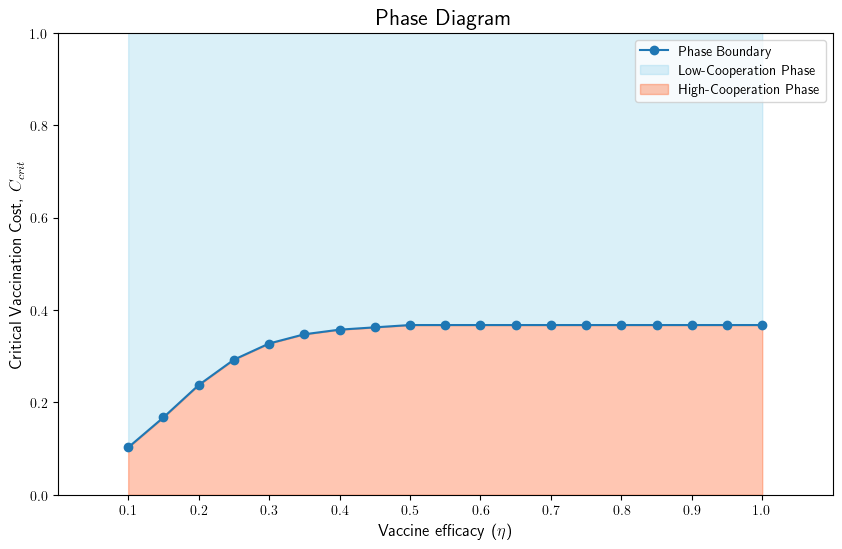

In [128]:
# 繪製相變邊界
plt.figure(figsize=(10, 6))
plt.plot(df_crit['eta'], df_crit['C_crit'], marker='o', linestyle='-', label='Phase Boundary')

# 填充相區域
plt.fill_between(df_crit['eta'], df_crit['C_crit'], 1, color='skyblue', alpha=0.3, label='Low-Cooperation Phase')
plt.fill_between(df_crit['eta'], df_crit['C_crit'], 0, color='orangered', alpha=0.3, label='High-Cooperation Phase')

print(plt.ylim())

# 圖表美化
plt.xticks(eta_values)

plt.title(label='Phase Diagram', fontsize=16)
plt.xlabel(r'Vaccine efficacy ($\eta$)', fontsize=12)
plt.ylabel(r'Critical Vaccination Cost, $C_{crit}$', fontsize=12)
# plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right')
plt.xlim(0, 1.1)
# plt.ylim(0, max(df_crit['C_crit']) * 1.05)
plt.ylim(0, 1)
# plt.savefig('phase_diagram.png')

# print("\n相圖已儲存為 phase_diagram.png")


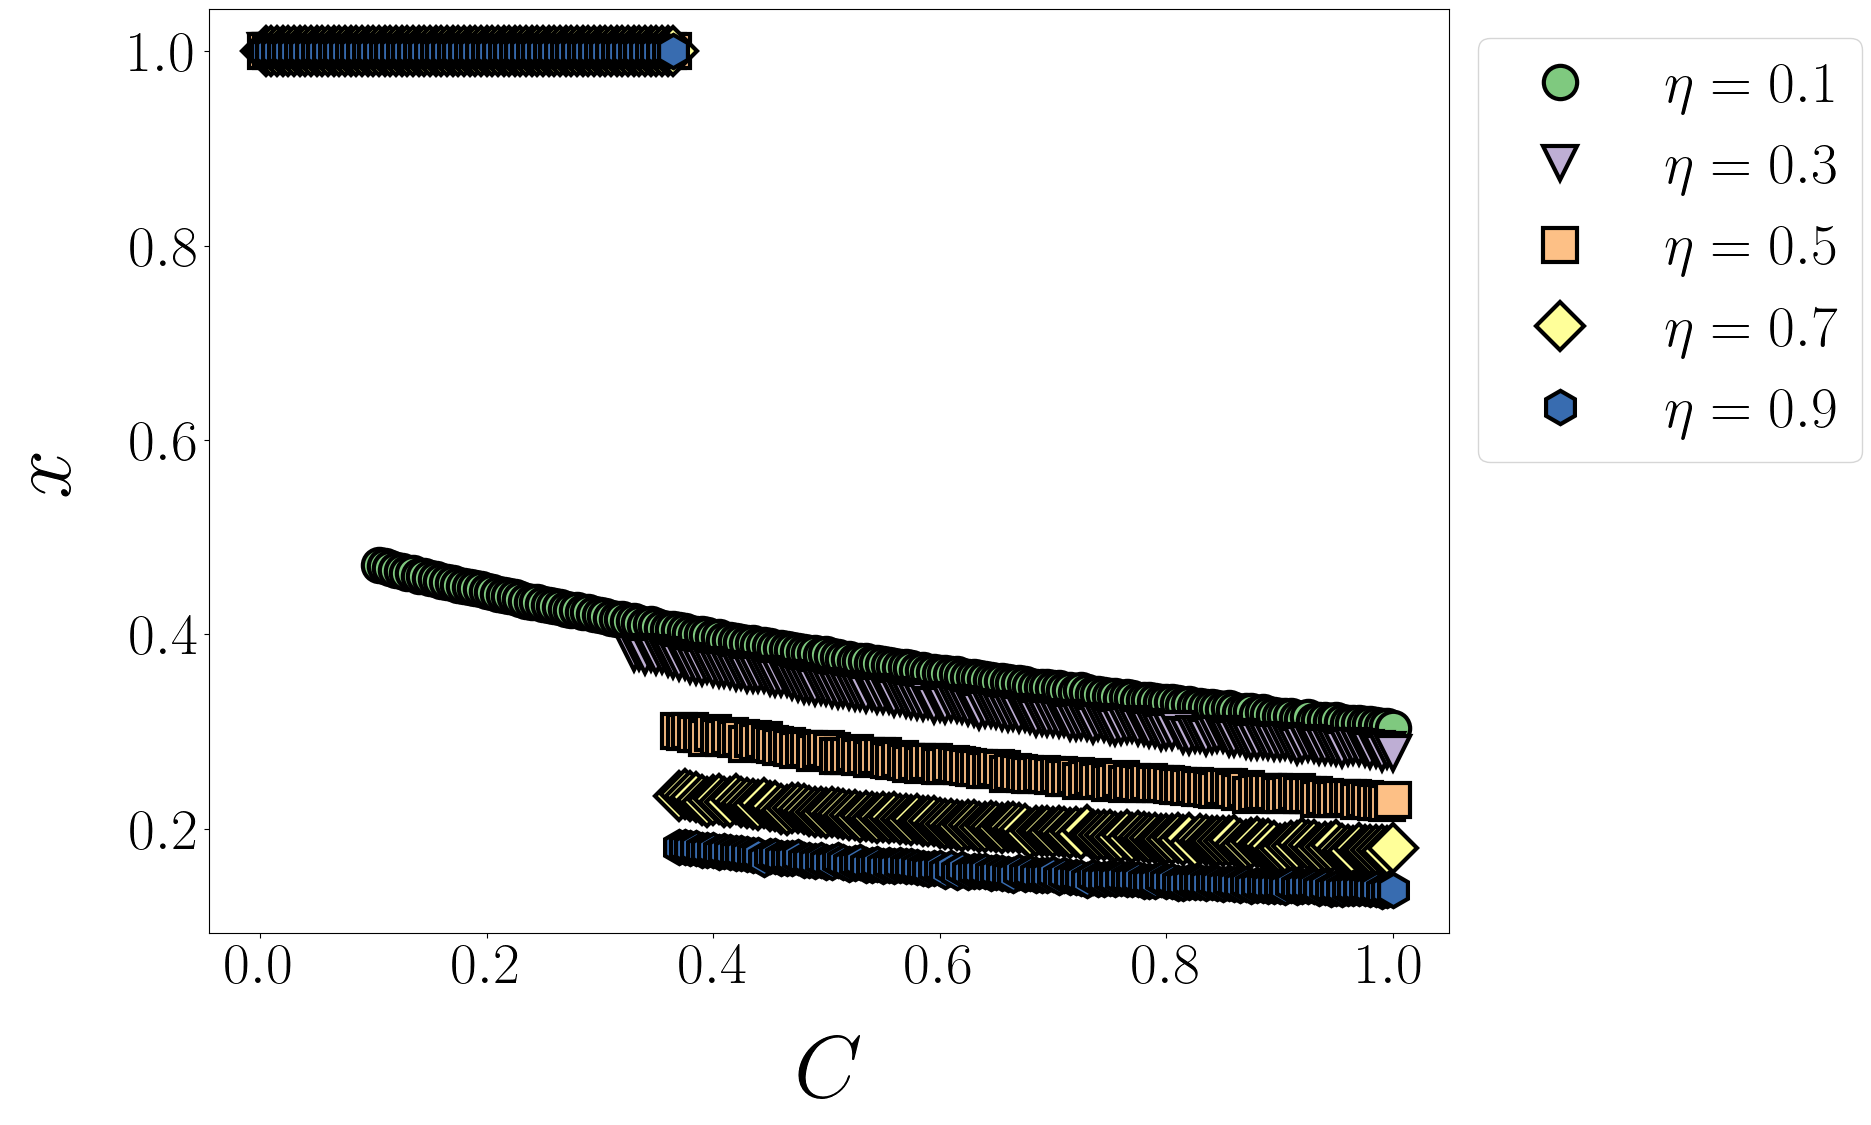

In [24]:
def plot_cross_section(data, dep_var, indep_var, fixed_param_sets):
    plt.figure(figsize=(16, 12))

    # Plot for each set of fixed parameters
    markers = ['o', 'v', 's', 'D', 'h', 'P']
    for i, fixed_params in enumerate(fixed_param_sets):
        # Filter the data
        filtered_data = data.copy()
        for param, value in fixed_params.items():
            if param in data.columns:
                filtered_data = filtered_data[filtered_data[param] == value]

        # Check if data is available
        if filtered_data.empty:
            print(f"No data available for {fixed_params}. Skipping.")
            continue

        # Generate label for the current line
        # label = ", ".join(f"{k}={v}" for k, v in fixed_params.items() if k != indep_var)
        vari = list(fixed_params.items())[-1][0]
        if vari != 'C':
            vari = f"\\{vari}"
        val = list(fixed_params.items())[-1][1]
        label = f"${vari} = {str(val)}$"
        
        # Plot the data
        marker = markers[i % len(markers)]
        # colors = ['darkblue', 'mediumblue', 'blue', 'royalblue', 'lightsteelblue']
        colors = plt.get_cmap('Accent').colors[:5]
        plt.plot(
            filtered_data[indep_var], 
            filtered_data[dep_var], 
            mfc=colors[i],                     # marker face color
            mew=3,                            # marker edge width
            mec='black',                      # marker edge color
            marker=marker, 
            linestyle='-', 
            label=label, 
            lw=0,
            markersize=24,
            )
    
    # Customize the plot
    if indep_var == 'C':
        plt.xlabel(f'${indep_var}$', fontsize=64, labelpad=30)
    else:
        plt.xlabel(f'$\\{indep_var}$', fontsize=64, labelpad=30)
    plt.ylabel(f'${dep_var}$', fontsize=64, labelpad=30)
    # plt.title(f'{dep_var} vs {indep_var} for multiple conditions', fontsize=16)
    plt.legend(fontsize=42, loc='upper left', bbox_to_anchor=(1, 1))
    # plt.grid(Fal)
    plt.tick_params(axis='both', which='major', labelsize=42)
    plt.show()
    
    return

plot_cross_section(
    df_H, 
    dep_var='x', 
    indep_var='C',
    fixed_param_sets=[
    {'beta': 0.8, 'gamma': 0.2, 'eta': 0.1},
    # {'beta': 0.8, 'gamma': 0.2, 'eta': 0.2},
    {'beta': 0.8, 'gamma': 0.2, 'eta': 0.3},
    # {'beta': 0.8, 'gamma': 0.2, 'eta': 0.4},
    {'beta': 0.8, 'gamma': 0.2, 'eta': 0.5},
    # {'beta': 0.8, 'gamma': 0.2, 'eta': 0.6},
    {'beta': 0.8, 'gamma': 0.2, 'eta': 0.7},
    # {'beta': 0.8, 'gamma': 0.2, 'eta': 0.8},
    {'beta': 0.8, 'gamma': 0.2, 'eta': 0.9},
    # {'beta': 0.8, 'gamma': 0.2, 'eta': 1},
    ]
    )

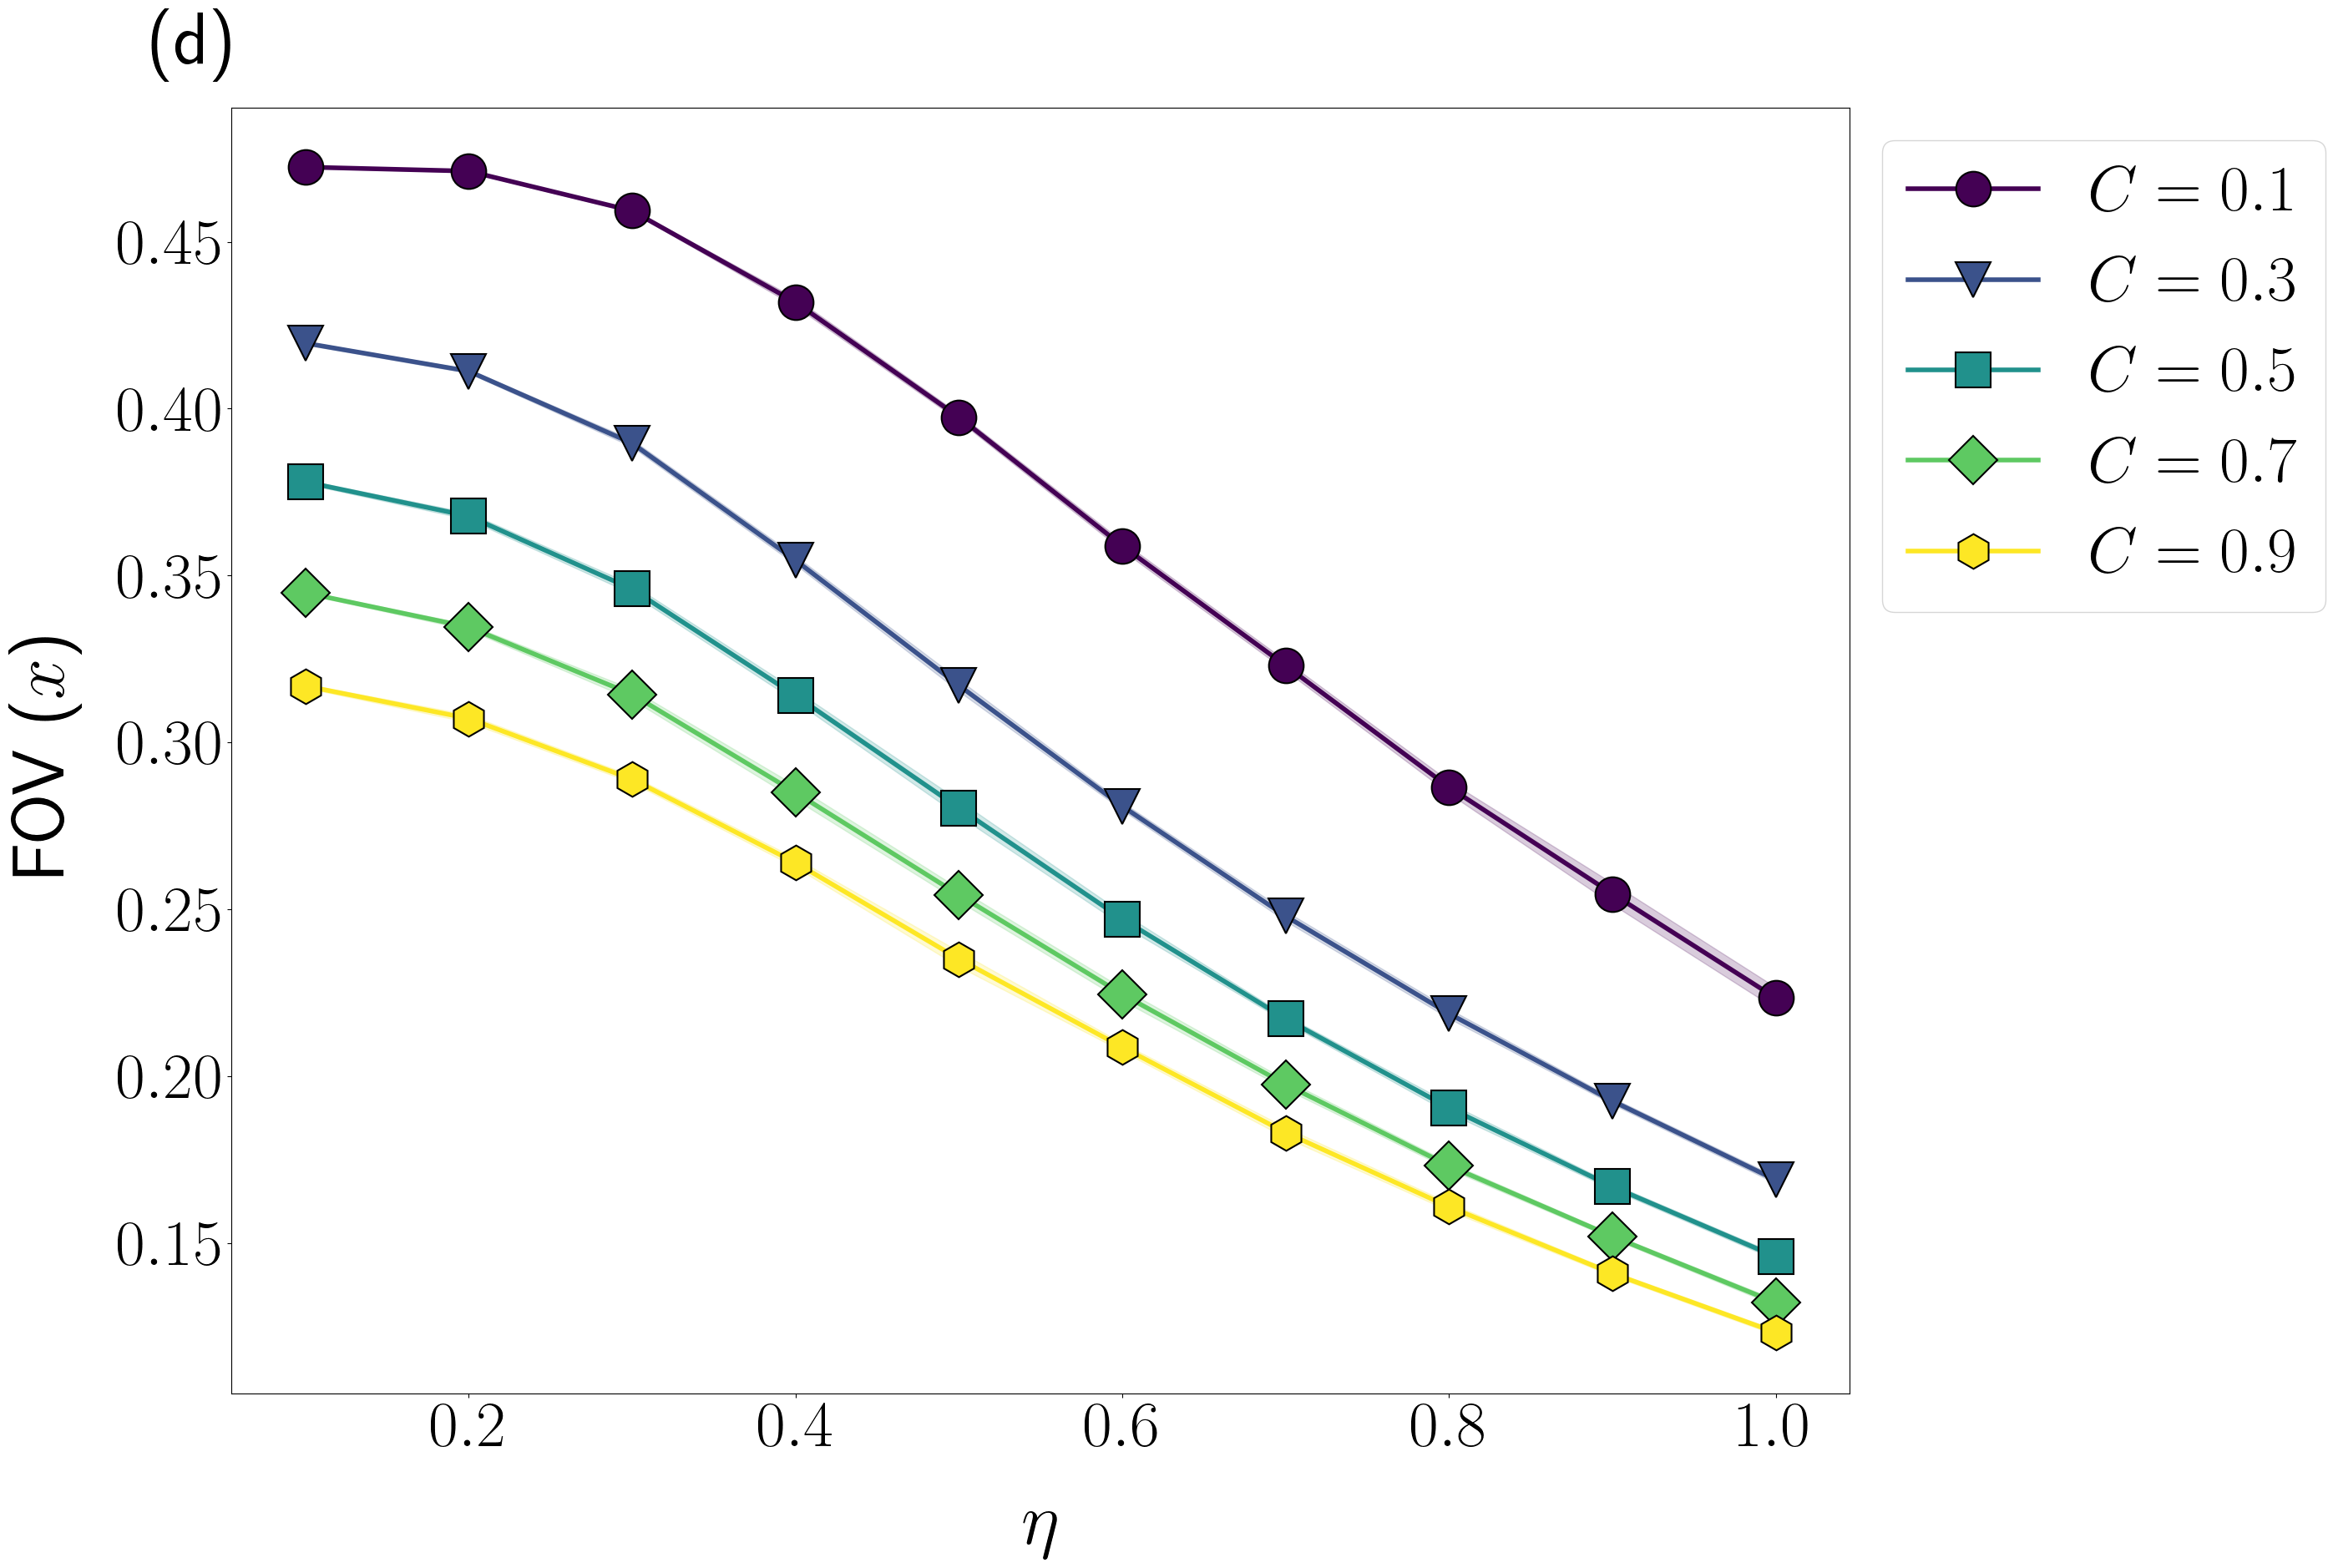

(<Figure size 2500x2000 with 1 Axes>,
 <Axes: xlabel='$\\eta$', ylabel='FOV ($x$)'>)

In [323]:
def plot_cross_section_with_std(data, dep_var_base, indep_var, fixed_param_sets):
    """
    (ax物件導向版本)
    Plots cross-section data, showing the mean as a line with markers 
    and the standard deviation as a shaded error band.
    """
    # === KEY CHANGE 1: 使用 subplots() 建立 fig 和 ax ===
    fig, ax = plt.subplots(figsize=(25, 20))
    
    mean_col = f"{dep_var_base}_mean"
    std_col = f"{dep_var_base}_std"

    markers = ['o', 'v', 's', 'D', 'h', 'P']
    cmap = plt.get_cmap('viridis')
    colors = cmap(np.linspace(0, 1, len(fixed_param_sets)))

    for i, fixed_params in enumerate(fixed_param_sets):
        filtered_data = data.copy()
        for param, value in fixed_params.items():
            if param in data.columns:
                filtered_data = filtered_data[filtered_data[param] == value]

        if filtered_data.empty:
            print(f"No data available for {fixed_params}. Skipping.")
            continue

        filtered_data = filtered_data.sort_values(by=indep_var)

        vari = list(fixed_params.items())[-1][0]
        if vari != 'C':
            vari = f"\\{vari}"
        val = list(fixed_params.items())[-1][1]
        label = f"${vari} = {str(val)}$"
        
        # === KEY CHANGE 2: 所有繪圖操作都從 plt. 改為 ax. ===
        # Plot the mean value line
        ax.plot(
            filtered_data[indep_var], 
            filtered_data[mean_col], 
            color=colors[i],
            marker=markers[i % len(markers)], 
            linestyle='-', 
            label=label, 
            lw=4,
            markersize=30,
            mew=1.5,
            mec='black'
        )
        
        # Plot the standard deviation as a shaded area
        ax.fill_between(
            filtered_data[indep_var],
            filtered_data[mean_col] - filtered_data[std_col],
            filtered_data[mean_col] + filtered_data[std_col],
            color=colors[i],
            alpha=0.2
        )
    
    # === KEY CHANGE 3: 所有客製化操作也都從 plt. 改為 ax.set_... ===
    if indep_var == 'C':
        ax.set_xlabel(f'${indep_var}$', fontsize=64, labelpad=30)
    else:
        ax.set_xlabel(f'$\\{indep_var}$', fontsize=64, labelpad=30)
    
    ax.set_ylabel(fr'FOV (${dep_var_base}$)', fontsize=64, labelpad=30)
    ax.legend(fontsize=56, loc='upper left', bbox_to_anchor=(1, 1))
    ax.tick_params(axis='both', which='major', labelsize=56)
    ax.text(-0.05, 1.02, '(d)', fontsize=64, transform=ax.transAxes, ha='left', va='bottom')
    # ax.grid(True, linestyle='--', alpha=0.5)
    
    # fig.tight_layout(rect=[0, 0, 0.85, 1])
    
    # 顯示圖表
    plt.show()
    
    # 讓函數回傳 fig 和 ax 物件，方便後續可能需要的微調
    return fig, ax

def get_agg_data(data):
    grouped_data = data[cols + ['x']].groupby(cols).agg(['mean', 'std'])
    flat_columns = ['_'.join(col).strip() for col in grouped_data.columns.values]
    grouped_data.columns = flat_columns
    grouped_data = grouped_data.reset_index()
    return grouped_data

df = pd.read_csv(p / 'Final_cross_section' / 'MC_sim.csv')

cols = ['C', 'eta', 'beta', 'gamma']

for col in ['C', 'eta', 'beta', 'gamma', 'theta']:
    df[col] = df[col].round(1)

df_PD = df[df['Game'] == 'PD']
df_H = df[df['Game'] == 'H']

data1 = df_PD[df_PD['run_id'] <= 10]                              # C=0.2, eta=0.8, gamma=0.1,0.3,0.5,0.7,0.9
data2 = df_PD[(df_PD['run_id'] > 10) & (df_PD['run_id'] <= 20)]   # C=0.2, eta=0.8, beta=0.1,0.3,0.5,0.7,0.9
data3 = df_PD[(df_PD['run_id'] > 20) & (df_PD['run_id'] <= 30)]   # beta=0.8, gamma=0.2

fixed_param = 'C'

# plot_cross_section_with_std(
#     data=get_agg_data(data2),
#     dep_var_base='x',
#     indep_var='gamma',
#     fixed_param_sets=[
#         {'C': 0.2, 'eta': 0.8, fixed_param: 0.1},
#         {'C': 0.2, 'eta': 0.8, fixed_param: 0.3},
#         {'C': 0.2, 'eta': 0.8, fixed_param: 0.5},
#         {'C': 0.2, 'eta': 0.8, fixed_param: 0.7},
#         {'C': 0.2, 'eta': 0.8, fixed_param: 0.9}
#     ]
# )

plot_cross_section_with_std(
    data=get_agg_data(data3),
    dep_var_base='x',
    indep_var='eta',
    fixed_param_sets=[
        {'gamma': 0.2, 'beta': 0.8, fixed_param: 0.1},
        {'gamma': 0.2, 'beta': 0.8, fixed_param: 0.3},
        {'gamma': 0.2, 'beta': 0.8, fixed_param: 0.5},
        {'gamma': 0.2, 'beta': 0.8, fixed_param: 0.7},
        {'gamma': 0.2, 'beta': 0.8, fixed_param: 0.9}
    ]
)

In [ ]:
# temp = pd.read_csv(p / 'Final_Heatmap' / 'Heatmap_(C,eta,beta,gamma)_param_space.csv')
# temp[(temp['C'] == 0.2) & (temp['eta'] == 0.8) & (temp['gamma'] == 0.1)]

# df_H[(df_H['C'] == 0.1) & (df_H['eta'] == 0.1)]

# output_path = p / '250711' / '100, PD, epsilon=0.01, DS=0.5, theta=0.1to10.csv.csv'
# df = run_sweep(
#     theta_values=[0.5],
#     M=400, N=400, 
#     Dr=-0.5, Dg=0.5, 
#     epsilon=0.001, 
#     grid_step=0.1, 
#     n_jobs=6, 
#     outfile=None
#     )

# df_H = run_init_sweep(
#         theta_values=[0.5],
#         M=400, N=400,
#         Dr=-0.5, Dg=-0.5,
#         epsilon=0.001,
#         init_step=0.02, n_jobs=6,
#         C=0.2, eta=0.75, beta=0.8, gamma=0.25,
# )

# df_PD = run_init_sweep(
#         theta_values=[0.5],
#         M=400, N=400,
#         Dr=0.5, Dg=0.5,
#         epsilon=0.001,
#         init_step=0.02, n_jobs=6,
#         C=0.2, eta=0.75, beta=0.8, gamma=0.25,
# )

# pd.concat([df_H, df_PD]).to_csv(p / 'Final_Heatmap' / 'Heatmap_init.csv', index=False)

# df.to_csv(p / '250711' / 'init, 400, SH, (Dr,Dg)=(0.5,-0.5), epsilon=0.001, (0.2,0.8,0.8,0.3), theta=0.5.csv', index=False)

In [8]:
# 右上角
param_grid = list(itertools.product(
    np.arange(0.7, 0.81, 0.1), # C
    np.arange(0.6, 1.01, 0.1), # eta
    np.arange(0.1, 1.01, 0.1), # beta
    np.arange(0.1, 1.01, 0.1)  # gamma
))


tasks = [
    (C, eta, beta, gamma, 0.5, -1, -1, 800, 800, 0.001)     # theta, Dr, Dg, M, N, epsilon
    for (C, eta, beta, gamma) in param_grid
]

# parallel settings
n_jobs = max(1, os.cpu_count() - 1)
os.environ['OMP_NUM_THREADS'] = '1'

results = Parallel(
    n_jobs=n_jobs,
    backend='loky',
    mmap_mode='r',
    # verbose=10
)(
    delayed(_process_one)(C, eta, beta, gamma, th, Dr, Dg, M, N, epsilon)
    for (C, eta, beta, gamma, th, Dr, Dg, M, N, epsilon) in tasks
)

partial_df = pd.DataFrame(results, columns=[
    'x', 'n', 'payoff_C', 'payoff_D', 'epi_size',
    'C', 'eta', 'beta', 'gamma', 'theta'
])

no display found. Using non-interactive Agg backend
no display found. Using non-interactive Agg backend
no display found. Using non-interactive Agg backend
no display found. Using non-interactive Agg backend
no display found. Using non-interactive Agg backend
no display found. Using non-interactive Agg backend
no display found. Using non-interactive Agg backend


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


0.7 0.6 0.1 0.7000000000000001
0.7 0.6 0.1 0.6000000000000001
0.7 0.6 0.1 0.5
0.7 0.6 0.1 0.8
0.7 0.6 0.1 0.9
0.7 0.6 0.1 1.0
0.7 0.6 0.1 0.4
0.7 0.6 0.1 0.30000000000000004
0.7 0.6 0.2 0.30000000000000004
0.7 0.6 0.2 0.4
0.7 0.6 0.1 0.2
0.7 0.6 0.2 0.5
0.7 0.6 0.2 0.8
0.7 0.6 0.2 0.7000000000000001
0.7 0.6 0.2 0.9
0.7 0.6 0.2 0.6000000000000001
0.7 0.6 0.2 1.0
0.7 0.6 0.30000000000000004 0.4
0.7 0.6 0.30000000000000004 0.5
0.7 0.6 0.2 0.2
0.7 0.6 0.1 0.1
0.7 0.6 0.30000000000000004 0.1
0.7 0.6 0.30000000000000004 0.6000000000000001
0.7 0.6 0.30000000000000004 0.7000000000000001
0.7 0.6 0.30000000000000004 1.0
0.7 0.6 0.30000000000000004 0.8
0.7 0.6 0.30000000000000004 0.9
0.7 0.6 0.30000000000000004 0.30000000000000004
0.7 0.6 0.2 0.1
0.7 0.6 0.4 0.6000000000000001
0.7 0.6 0.30000000000000004 0.2
0.7 0.6 0.4 0.1
0.7 0.6 0.4 0.2
0.7 0.6 0.4 0.9
0.7 0.6 0.4 0.5
0.7 0.6 0.4 0.8
0.7 0.6 0.4 0.7000000000000001
0.7 0.6 0.4 1.0
0.7 0.6 0.4 0.4
0.7 0.6 0.4 0.30000000000000004
0.7 0.6 0.5 0.2


In [12]:
# partial_df.to_csv(p / '250711' / '800_Harmony_epsilon=0.001_partial.csv', index=False)
df.to_csv(p / '250711' / '400, CH, epsilon=0.001, (Dr,Dg)=(-0.5,0.5), theta=0.5.csv', index=False)

In [ ]:
def get_double_plot(data, col='x', title='Model2'):
    # Get unique values for outer and inner axes
    outer_x = sorted(data['C'].unique())
    outer_y = sorted(data['eta'].unique(), reverse=True)
    inner_x = sorted(data['beta'].unique())
    inner_y = sorted(data['gamma'].unique())

    # Pre-compute pivot tables for efficiency
    pivot_tables = {}
    for eta in outer_y:
        for C in outer_x:
            subset = data[(data['C'] == C) & (data['eta'] == eta)]
            pivot_tables[(eta, C)] = subset.pivot(index='gamma', columns='beta', values=col)

    # Create a grid of subplots
    fig, axes = plt.subplots(len(outer_y), len(outer_x), figsize=(20, 20), sharex=False, sharey=False)
    fig.subplots_adjust(wspace=0.1, hspace=0.1)

    # min and max for heat maps
    if col == 'payoff_D':
        # payoff_D <= 0 because D'_g = -1
        vmin = -1
        vmax = 0
    elif col == 'payoff_C':
        vmin = -1
        vmax = 1
    else:
        vmin = 0
        vmax = 1

    # Iterate over the outer grid
    for i, eta in enumerate(outer_y):
        for j, C in enumerate(outer_x):
            # # Retrieve pre-computed pivot table
            # pivot_table = pivot_tables[(eta, C)]
            
            # # Plot the inner heatmap
            # ax = axes[i, j]
            # sns.heatmap(pivot_table[::-1], ax=ax, cbar=False,
            #             cbar_kws={"shrink": 0.8}, vmin=vmin, vmax=vmax, cmap="viridis")
            
            # # Set inner ticks
            # ax.set_xticks([0.5, len(inner_x) - 0.5])
            # ax.set_xticklabels([".1", "1"], fontsize=28)
            # ax.set_yticks([0.5, len(inner_y) - 0.5])
            # ax.set_yticklabels([".1", "1"], fontsize=28)

            ax = axes[i, j]
            sns.heatmap(pivot_tables[(eta, C)][::-1],
                        ax=ax, cbar=False,
                        vmin=vmin, vmax=vmax, cmap="viridis")

            # ── 只在最左下角保留 ticks ─────────────────────────
            if i == len(outer_y) - 1 and j == 0:          # 左下角
                ax.set_xticks([0.5, len(inner_x) - 0.5])
                ax.set_xticklabels(["0.1", "1"], fontsize=32, rotation=0)
                ax.set_yticks([0.5, len(inner_y) - 0.5])
                ax.set_yticklabels(["1", "0.1"], fontsize=32, rotation=0)
            else:                                         # 其他子圖清空
                ax.set_xticks([]);  ax.set_yticks([])

    # print(pivot_tables[(1, 1)])

    # Add overall outer x and y labels
    fig.text(0.5, 0.06, '$C$', ha='center', va='center', fontsize=42)
    fig.text(0.06, 0.5, '$\\eta$', ha='center', va='center', rotation=0, fontsize=42)

    # Add inner x and y labels for the left-below subplot
    axes[-1, 0].set_xlabel('$\\beta$', fontsize=42, labelpad=10)
    axes[-1, 0].set_ylabel('$\\gamma$', va='center', fontsize=42, labelpad=15, rotation=0)

    # # Remove unnecessary labels
    for i, ax_row in enumerate(axes):
        for j, ax in enumerate(ax_row):
            if not (i == len(outer_y) - 1 and j == 0):
                ax.set_xlabel('')
                ax.set_ylabel('')
                # ax.set_xticklabels([])
                # ax.set_yticklabels([])

    # Add an overall colorbar
    norm = plt.Normalize(vmin=vmin, vmax=vmax)
    cbar = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap="viridis"), ax=axes, orientation='vertical', fraction=0.04, pad=0.03)
    ticklabs = cbar.ax.get_yticklabels()
    cbar.ax.set_yticklabels(ticklabs, fontsize=32)

    # plt.suptitle(f'{title}, {col}', y=0.9, fontsize=32)
    plt.show()
    return

def plot_x0n0_heatmap(
    data: pd.DataFrame,
    *,                    # 之後全都是 keyword‑only
    col: str = 'x',       # 要畫哪一欄
    C: float | None = None,
    eta: float | None = None,
    beta: float | None = None,
    gamma: float | None = None,
    theta: float | None = None,
    vmin: float | None = None,
    vmax: float | None = None,
    title: str | None = None,
    figsize=(6, 5),
):
    """
    畫一張 10×10 heat‑map：橫 x0, 縱 n0。
    若指定 C/eta/beta/gamma/theta，則先 filter，再 pivot。
    """
    # -------- 1. 依指定參數篩選資料 ---------------------------
    mask = np.ones(len(data), dtype=bool)
    for name, val in [('C', C), ('eta', eta),
                      ('beta', beta), ('gamma', gamma),
                      ('theta', theta)]:
        if val is not None:
            mask &= np.isclose(data[name], val)
    df = data.loc[mask, ['x0', 'n0', col]]
    # print(df)
    if df.empty:
        raise ValueError("篩選後沒有資料，請確認參數是否正確。")

    # -------- 2. 做 pivot，並補齊 0.1‥1.0 的格點 -------------
    grid = np.round(np.arange(0.1, 1.0 + 1e-8, 0.1), 1)
    pivot = (
        df.pivot(index='n0', columns='x0', values=col)
          .reindex(index=grid, columns=grid)         # 補 NaN
          .sort_index(ascending=False)               # n0 由 1→0.1
    )

    # -------- 3. vmin/vmax 預設 -------------------------------
    if vmin is None or vmax is None:
        if col == 'payoff_D':
            vmin, vmax = -1, 0
        elif col == 'payoff_C':
            vmin, vmax = -1, 1
        else:
            vmin = 0
            vmax = 1

    # -------- 4. 繪圖 ----------------------------------------
    # plt.figure(figsize=figsize)
    fig, ax = plt.subplots(
        figsize=figsize, sharex=False, sharey=False
    )
    sns.heatmap(
        pivot,
        ax=ax,
        cmap='viridis',
        vmin=vmin, vmax=vmax,
        linewidths=0, linecolor='white',  # 讓 NaN 方格邊界明顯
        cbar=False
    )

    sm = plt.cm.ScalarMappable(norm=plt.Normalize(vmin=vmin, vmax=vmax),
                               cmap="viridis")
    cbar = fig.colorbar(sm, ax=ax, orientation='vertical',
                        fraction=0.04, pad=0.03)
    cbar.ax.tick_params(labelsize=32)

    # 軸標籤 & tick
    plt.xlabel(r'$x_0$', fontsize=42)
    plt.ylabel(r'$n_0$', fontsize=42, rotation=0, labelpad=15)
    plt.xticks([0.5, 9.5], ['0.1', '1.0'])          # 只留兩端 tick
    plt.yticks([0.5, 9.5], ['1.0', '0.1'])
    ax.set_xticklabels(["0.1", "1"], fontsize=32, rotation=0)
    ax.set_yticklabels(["0.1", "1"], fontsize=32, rotation=0)

    if title:
        plt.title(title, fontsize=42, pad=12)
    plt.tight_layout()
    plt.show()

key_cols = ['x0', 'n0', 'C', 'eta', 'beta', 'gamma']

for col in key_cols:
    df[col] = df[col].round(3)

# plot_x0n0_heatmap(df, col='x', C=0.2, eta=0.8, beta=0.8, gamma=0.3, theta=0.5, figsize=(12,10))
df
# df

,x,n,payoff_C,payoff_D,epi_size,C,eta,beta,gamma,theta,x0,n0
0,0.122143,0.000010,-0.025784,-0.025512,0.027465,0.2,0.8,0.8,0.3,0.5,0.0,0.0
1,0.113187,0.000010,-0.023820,-0.023861,0.025619,0.2,0.8,0.8,0.3,0.5,0.0,0.0
2,0.112510,0.000010,-0.023781,-0.023842,0.025863,0.2,0.8,0.8,0.3,0.5,0.0,0.1
3,0.112549,0.000010,-0.023661,-0.023898,0.025770,0.2,0.8,0.8,0.3,0.5,0.0,0.1
4,0.117798,0.000010,-0.024750,-0.024368,0.026126,0.2,0.8,0.8,0.3,0.5,0.0,0.1
...,...,...,...,...,...,...,...,...,...,...,...,...
2495,0.999990,0.999614,0.998164,0.000000,0.000963,0.2,0.8,0.8,0.3,0.5,1.0,0.9
2496,0.999990,0.999616,0.998198,0.000000,0.000932,0.2,0.8,0.8,0.3,0.5,1.0,0.9
2497,0.999990,0.999615,0.998203,0.000000,0.000945,0.2,0.8,0.8,0.3,0.5,1.0,1.0
2498,0.999990,0.999617,0.998315,0.000000,0.000870,0.2,0.8,0.8,0.3,0.5,1.0,1.0


### SIRV Model

The following classes are mainly based on a package called NDlib (Network Diffusion Library). For the simulations of SIRV Model, I make some modifications to the source code of "DiffusionModel" and "SIRModel" provided by the package.

0: Susceptible 

1: Vaccinated 

2: Infected 

3: Recovered

In [2]:
import abc
import warnings
# import numpy as np
import past.builtins
# import future.utils
import six
from netdispatch import AGraph
import tqdm

__author__ = "Giulio Rossetti"
__license__ = "BSD-2-Clause"
__email__ = "giulio.rossetti@gmail.com"


class ConfigurationException(Exception):
    """Configuration Exception"""


@six.add_metaclass(abc.ABCMeta)
class DiffusionModel(object):
    """
    Partial Abstract Class that defines Diffusion Models
    """

    # __metaclass__ = abc.ABCMeta

    def __init__(self, graph, seed=None):
        """
        Model Constructor

        :param graph: A networkx graph object
        """

        np.random.seed(seed)

        self.discrete_state = True

        self.params = {"nodes": {}, "edges": {}, "model": {}, "status": {}}

        self.available_statuses = {
            "Susceptible": 0,
            "Infected": 1,
            "Recovered": 2,
            "Blocked": -1,
        }

        self.name = ""

        self.parameters = {"model": {}, "nodes": {}, "edges": {}}

        self.actual_iteration = 0
        self.graph = AGraph(graph)
        self.status = {n: 0 for n in self.graph.nodes}
        self.initial_status = {}

    def __validate_configuration(self, configuration):
        """
        Validate the consistency of a Configuration object for the specific model

        :param configuration: a Configuration object instance
        """
        if "Infected" not in self.available_statuses:
            raise ConfigurationException("'Infected' status not defined.")

        # Checking mandatory parameters
        omp = set(
            [
                k
                for k in self.parameters["model"].keys()
                if not self.parameters["model"][k]["optional"]
            ]
        )
        onp = set(
            [
                k
                for k in self.parameters["nodes"].keys()
                if not self.parameters["nodes"][k]["optional"]
            ]
        )
        oep = set(
            [
                k
                for k in self.parameters["edges"].keys()
                if not self.parameters["edges"][k]["optional"]
            ]
        )

        mdp = set(configuration.get_model_parameters().keys())
        ndp = set(configuration.get_nodes_configuration().keys())
        edp = set(configuration.get_edges_configuration().keys())

        if len(omp) > 0:
            if len(omp & mdp) != len(omp):
                raise ConfigurationException(
                    {
                        "message": "Missing mandatory model parameter(s)",
                        "parameters": omp - mdp,
                    }
                )

        if len(onp) > 0:
            if len(onp & ndp) != len(onp):
                raise ConfigurationException(
                    {
                        "message": "Missing mandatory node parameter(s)",
                        "parameters": onp - ndp,
                    }
                )

        if len(oep) > 0:
            if len(oep & edp) != len(oep):
                raise ConfigurationException(
                    {
                        "message": "Missing mandatory edge parameter(s)",
                        "parameters": oep - edp,
                    }
                )

        # Checking optional parameters
        omp = set(
            [
                k
                for k in self.parameters["model"].keys()
                if self.parameters["model"][k]["optional"]
            ]
        )
        onp = set(
            [
                k
                for k in self.parameters["nodes"].keys()
                if self.parameters["nodes"][k]["optional"]
            ]
        )
        oep = set(
            [
                k
                for k in self.parameters["edges"].keys()
                if self.parameters["edges"][k]["optional"]
            ]
        )

        if len(omp) > 0:
            for param in omp:
                if param not in mdp:
                    configuration.add_model_parameter(
                        param, self.parameters["model"][param]["default"]
                    )

        if len(onp) > 0:
            for param in onp:
                if param not in ndp:
                    for nid in self.graph.nodes:
                        configuration.add_node_configuration(
                            param, nid, self.parameters["nodes"][param]["default"]
                        )

        if len(oep) > 0:
            for param in oep:
                if param not in edp:
                    for eid in self.graph.edges:
                        configuration.add_edge_configuration(
                            param, eid, self.parameters["edges"][param]["default"]
                        )

        # Checking initial simulation status
        sts = set(configuration.get_model_configuration().keys())
        if (
            self.discrete_state
            and "Infected" not in sts
            and "fraction_infected" not in mdp
            and "percentage_infected" not in mdp
        ):
            warnings.warn(
                "Initial infection missing: a random sample of 5% of graph nodes will be set as infected"
            )
            self.params["model"]["fraction_infected"] = 0.05

    def set_initial_status(self, configuration):
        """
        Set the initial model configuration

        :param configuration: a ```ndlib.models.ModelConfig.Configuration``` object
        """

        self.__validate_configuration(configuration)

        nodes_cfg = configuration.get_nodes_configuration()
        # Set additional node information

        for param, node_to_value in future.utils.iteritems(nodes_cfg):
            if len(node_to_value) < len(self.graph.nodes):
                raise ConfigurationException(
                    {"message": "Not all nodes have a configuration specified"}
                )

            self.params["nodes"][param] = node_to_value

        edges_cfg = configuration.get_edges_configuration()
        # Set additional edges information
        for param, edge_to_values in future.utils.iteritems(edges_cfg):
            if len(edge_to_values) == len(self.graph.edges):
                self.params["edges"][param] = {}
                for e in edge_to_values:
                    self.params["edges"][param][e] = edge_to_values[e]

        # Set initial status

        model_status = configuration.get_model_configuration()

        for param, nodes in future.utils.iteritems(model_status):
            self.params["status"][param] = nodes
            for node in nodes:
                self.status[node] = self.available_statuses[param]

        # Set model additional information
        model_params = configuration.get_model_parameters()
        for param, val in future.utils.iteritems(model_params):
            self.params["model"][param] = val

        # Handle initial infection
        if "Infected" not in self.params["status"]:
            if "percentage_infected" in self.params["model"]:
                self.params["model"]["fraction_infected"] = self.params["model"][
                    "percentage_infected"
                ]
            if "fraction_infected" in self.params["model"]:
                number_of_initial_infected = self.graph.number_of_nodes() * float(
                    self.params["model"]["fraction_infected"]
                )
                if number_of_initial_infected < 1:
                    warnings.warn(
                        "The fraction_infected value is too low given the number of nodes of the selected graph: a "
                        "single node will be set as infected"
                    )
                    number_of_initial_infected = 1

                available_nodes = [n for n in self.status if self.status[n] == 0]
                # 1010: np.random.choice 只能用在 1-d array 上
                sampled_nodes = sample(available_nodes, int(number_of_initial_infected))
                # sampled_nodes = np.random.choice(
                #     available_nodes, int(number_of_initial_infected), replace=False
                # )
                for k in sampled_nodes:
                    self.status[k] = self.available_statuses["Infected"]

        # ====================
        # Set vaccinated nodes
        # ====================
        if "fraction_vaccinated" in self.params["model"]:

            # 0814: 如果 fraction_vaccinated + fraction_infected > 1，則 fraction_infected 優先，剩下的節點才設為 vaccinated
            if self.params["model"]["fraction_infected"] + self.params["model"]["fraction_vaccinated"] >= 1:
                number_of_initial_vaccinated = self.graph.number_of_nodes() - number_of_initial_infected
            else:
                number_of_initial_vaccinated = self.graph.number_of_nodes() * float(
                    self.params["model"]["fraction_vaccinated"]
                )
                if number_of_initial_vaccinated < 1:
                    warnings.warn(
                        "The fraction_vaccinated value is too low given the number of nodes of the selected graph: a"
                        "single node will be set as infected"
                    )
                    number_of_initial_vaccinated = 1
            
            available_nodes = [n for n in self.status if self.status[n] == 0]
            # 1010: np.random.choice 只能用在 1-d array 上
            sampled_nodes = sample(available_nodes, int(number_of_initial_vaccinated))
            # sampled_nodes = np.random.choice(
            #     available_nodes, int(number_of_initial_vaccinated), replace=False
            # )
            for k in sampled_nodes:
                self.status[k] = self.available_statuses["Vaccinated"]

        self.initial_status = self.status

    def clean_initial_status(self, valid_status=None):
        """
        Check the consistency of initial status
        :param valid_status: valid node configurations
        """
        for n, s in future.utils.iteritems(self.status):
            if s not in valid_status:
                self.status[n] = 0

    def iteration_bunch(self, bunch_size, node_status=True, progress_bar=False):
        """
        Execute a bunch of model iterations

        :param bunch_size: the number of iterations to execute
        :param node_status: if the incremental node status has to be returned.
        :param progress_bar: whether to display a progress bar, default False

        :return: a list containing for each iteration a dictionary {"iteration": iteration_id, "status": dictionary_node_to_status}
        """
        system_status = []
        for it in tqdm.tqdm(
            past.builtins.xrange(0, bunch_size), disable=not progress_bar
        ):
            its = self.iteration(node_status)
            system_status.append(its)

            # 提早結束 0 (susceptible) + 1 (vaccinated) = 0  or 2 (infected) = 0
            # print(its["node_count"][0], its["node_count"][2])
            if (its["node_count"][0] + its["node_count"][1]) * its["node_count"][2] == 0:
                break
        return system_status

    def get_info(self):
        """
        Describes the current model parameters (nodes, edges, status)

        :return: a dictionary containing for each parameter class the values specified during model configuration
        """
        info = {
            k: v
            for k, v in future.utils.iteritems(self.params)
            if k not in ["nodes", "edges", "status"]
        }
        if "infected_nodes" in self.params["status"]:
            info["selected_initial_infected"] = True
        return info["model"]

    def reset(self, infected_nodes=None):
        """
        Reset the simulation setting the actual status to the initial configuration.
        """
        self.actual_iteration = 0

        if infected_nodes is not None:
            for n in self.status:
                self.status[n] = 0
            for n in infected_nodes:
                self.status[n] = self.available_statuses["Infected"]
            self.initial_status = self.status

        else:
            if "percentage_infected" in self.params["model"]:
                self.params["model"]["fraction_infected"] = self.params["model"][
                    "percentage_infected"
                ]
            if "fraction_infected" in self.params["model"]:
                for n in self.status:
                    self.status[n] = 0
                number_of_initial_infected = self.graph.number_of_nodes() * float(
                    self.params["model"]["fraction_infected"]
                )
                available_nodes = [n for n in self.status if self.status[n] == 0]
                # 1010: np.random.choice 只能用在 1-d array 上
                sampled_nodes = sample(available_nodes, int(number_of_initial_infected))
                # sampled_nodes = np.random.choice(
                #     available_nodes, int(number_of_initial_infected), replace=False
                # )

                for k in sampled_nodes:
                    self.status[k] = self.available_statuses["Infected"]

                self.initial_status = self.status
            else:
                self.status = self.initial_status

            # ====================
            # Set vaccinated nodes
            # ====================
            if "fraction_vaccinated" in self.params["model"]:
                number_of_initial_vaccinated = self.graph.number_of_nodes() * float(
                    self.params["model"]["fraction_vaccinated"]
                )
                if number_of_initial_vaccinated < 1:
                    warnings.warn(
                        "The fraction_vaccinated value is too low given the number of nodes of the selected graph: a"
                        "single node will be set as infected"
                    )
                    number_of_initial_vaccinated = 1
                
                available_nodes = [n for n in self.status if self.status[n] == 0]
                # 1010: np.random.choice 只能用在 1-d array 上
                sampled_nodes = sample(available_nodes, int(number_of_initial_vaccinated))
                # sampled_nodes = np.random.choice(
                #     available_nodes, int(number_of_initial_vaccinated), replace=False
                # )
                for k in sampled_nodes:
                    self.status[k] = self.available_statuses["Vaccinated"]

        return self

    def get_model_parameters(self):
        return self.parameters

    def get_name(self):
        return self.name

    def get_status_map(self):
        """
        Specify the statuses allowed by the model and their numeric code

        :return: a dictionary (status->code)
        """
        return self.available_statuses

    @abc.abstractmethod
    def iteration(self, node_status=True):
        """
        Execute a single model iteration

        :param node_status: if the incremental node status has to be returned.

        :return: Iteration_id,
                 (optional) Incremental node status (dictionary node->status),
                 Status count (dictionary status->node count),
                 Status delta (dictionary status->node delta)
        """
        pass

    @staticmethod
    def check_status_similarity(actual, previous):
        """
        Evaluate similarity among statuses

        :param actual: actual status
        :param previous: previous status
        :return: True if the two statuses are the same, False otherwise
        """
        for n, v in future.utils.iteritems(actual):
            if n not in previous:
                return False
            if previous[n] != actual[n]:
                return False
        return True

    def status_delta(self, actual_status):
        """
        Compute the point-to-point variations for each status w.r.t. the previous system configuration

        :param actual_status: the actual simulation status
        :return: node that have changed their statuses (dictionary status->nodes),
                 count of actual nodes per status (dictionary status->node count),
                 delta of nodes per status w.r.t the previous configuration (dictionary status->delta)
        """
        actual_status_count = {}
        old_status_count = {}
        delta = {}
        for n, v in future.utils.iteritems(self.status):
            if v != actual_status[n]:
                delta[n] = actual_status[n]

        for st in list(self.available_statuses.values()):
            actual_status_count[st] = len(
                [x for x in actual_status if actual_status[x] == st]
            )
            old_status_count[st] = len([x for x in self.status if self.status[x] == st])

        status_delta = {
            st: actual_status_count[st] - old_status_count[st]
            for st in actual_status_count
        }

        return delta, actual_status_count, status_delta

    def status_delta_continuous(self, actual_status):
        """
        Compute the point-to-point variations for each status w.r.t. the previous system configuration

        Should be used for continuous statuses instead of discrete values

        :param actual_status: the actual simulation status
        :return: nodes that have changed their statuses (dictionary status->nodes),
                    count of actual nodes per status (dictionary status->node count),
                    delta of nodes per status w.r.t the previous configuration (dictionary status->delta)
        """
        delta = {}
        status_delta = {}
        for n, v in future.utils.iteritems(self.status):
            delta[n] = {}
            status_delta[n] = {}
            for var, val in v.items():
                if val != actual_status[n][var]:
                    delta[n][var] = actual_status[n][var]
                    status_delta[n][var] = actual_status[n][var] - val
            if len(delta[n].values()) == 0:
                del delta[n]
            if len(status_delta[n].values()) == 0:
                del status_delta[n]

        return delta, status_delta

    def build_trends(self, iterations):
        """
        Build node status and node delta trends from model iteration bunch

        :param iterations: a set of iterations
        :return: a trend description
        """
        status_delta = {status: [] for status in self.available_statuses.values()}
        node_count = {status: [] for status in self.available_statuses.values()}

        for it in iterations:
            for st in self.available_statuses.values():
                try:
                    status_delta[st].append(it["status_delta"][st])
                    node_count[st].append(it["node_count"][st])
                except:
                    status_delta[st].append(it["status_delta"][str(st)])
                    node_count[st].append(it["node_count"][str(st)])

        return [{"trends": {"node_count": node_count, "status_delta": status_delta}}]


In [3]:
__author__ = "Giulio Rossetti"
__license__ = "BSD-2-Clause"
__email__ = "giulio.rossetti@gmail.com"

class SIRVModel(DiffusionModel):
    """
    Model Parameters to be specified via ModelConfig

    :param beta: The infection rate (float value in [0,1])
    :param gamma: The recovery rate (float value in [0,1])
    """

    def __init__(self, graph, seed=None):
        """
        Model Constructor

        :param graph: A networkx graph object
        """
        super(self.__class__, self).__init__(graph, seed)
        self.available_statuses = {"Susceptible": 0, "Vaccinated": 1, "Infected": 2, "Recovered": 3}

        self.parameters = {
            "model": {
                "beta": {"descr": "Infection rate", "range": [0, 1], "optional": False},
                "gamma": {"descr": "Recovery rate", "range": [0, 1], "optional": False},
                "tp_rate": {
                    "descr": "Whether if the infection rate depends on the number of infected neighbors",
                    "range": [0, 1],
                    "optional": True,
                    "default": 1,
                },
            },
            "nodes": {},
            "edges": {},
        }

        self.active = []
        self.name = "SIRV"

    def iteration(self, node_status=True):
        """
        Execute a single model iteration

        :return: Iteration_id, Incremental node status (dictionary node->status)
        """
        self.clean_initial_status(self.available_statuses.values())

        actual_status = {
            node: nstatus for node, nstatus in future.utils.iteritems(self.status)
        }
        # ====================
        # Infected / Recovered nodes
        # ====================
        self.active = [
            node
            for node, nstatus in future.utils.iteritems(self.status)
            if nstatus > self.available_statuses["Vaccinated"]
        ]

        if self.actual_iteration == 0:
            self.actual_iteration += 1
            delta, node_count, status_delta = self.status_delta(actual_status)
            if node_status:
                return {
                    "iteration": 0,
                    "status": actual_status.copy(),
                    "node_count": node_count.copy(),
                    "status_delta": status_delta.copy(),
                }
            else:
                return {
                    "iteration": 0,
                    "status": {},
                    "node_count": node_count.copy(),
                    "status_delta": status_delta.copy(),
                }

        for u in self.active:

            u_status = self.status[u]

            # infected nodes
            if u_status == 2:

                # susceptible neighbors
                if self.graph.directed:
                    susceptible_neighbors = [
                        v for v in self.graph.successors(u) if self.status[v] == 0
                    ]
                else:
                    susceptible_neighbors = [
                        v for v in self.graph.neighbors(u) if self.status[v] == 0
                    ]
                for v in susceptible_neighbors:
                    eventp = np.random.random_sample()
                    if eventp < self.params["model"]["beta"]:
                        actual_status[v] = 2
                        # print("susceptible", eventp, '<', self.params["model"]["beta"])

                # ====================
                # vaccinated neighbors
                # ====================
                vaccinated_neighbors = [
                    v for v in self.graph.neighbors(u) if self.status[v] == 1
                ]
                for v in vaccinated_neighbors:
                    eventp = np.random.random_sample()
                    if eventp < self.params["model"]["beta"] * (1 - self.params["model"]["eta"]):
                        actual_status[v] = 2
                        # print("vaccinated", eventp, '<', self.params["model"]["beta"] * (1 - self.params["model"]["eta"]))
                
                eventp = np.random.random_sample()
                if eventp < self.params["model"]["gamma"]:
                    actual_status[u] = 3

        delta, node_count, status_delta = self.status_delta(actual_status)
        self.status = actual_status
        self.actual_iteration += 1

        if node_status:
            return {
                "iteration": self.actual_iteration - 1,
                "status": delta.copy(),
                "node_count": node_count.copy(),
                "status_delta": status_delta.copy(),
            }
        else:
            return {
                "iteration": self.actual_iteration - 1,
                "status": {},
                "node_count": node_count.copy(),
                "status_delta": status_delta.copy(),
            }

### Local timescale

For more convenient observation, the following functions have not been integrated into a class yet.

In [2]:
# functions of local time

def config(params: dict):
    cfg = mc.Configuration()
    cfg.add_model_parameter("beta", params["beta"])
    cfg.add_model_parameter("gamma", params["gamma"])
    cfg.add_model_parameter("eta", params["eta"])
    cfg.add_model_parameter("fraction_infected", params["fraction_infected"])
    cfg.add_model_parameter("fraction_vaccinated", params["fraction_vaccinated"])

    return cfg

def set_SIRVModel(g, cfg):
    '''
    g: Network topology
    cfg: Model configuration
    '''

    SIRV = SIRVModel(g)
    SIRV.set_initial_status(cfg)

    return SIRV

def run_iterations(model, bunch_size=1000):
    '''
    It is designed so that as long as the number of infected people becomes 0, the iteration will stop even if the bunch size has not yet been reached.
    '''

    iterations = model.iteration_bunch(bunch_size, progress_bar=True)
    return iterations

### 單次 Local time

In [5]:
beta = 5/6 # transmission rate
gamma = 1/3 # recovery rate
epsilon = 0.00001 # fraction infected
x = 0.417861 # fraction vaccinated
eta = 0.5 # vaccine efficacy

params = {
    "beta": beta, 
    "gamma": gamma, 
    "eta": eta, 
    "fraction_infected": epsilon, 
    "fraction_vaccinated": x
}

# Network topology
# g = nx.complete_graph(500)
# g = nx.random_regular_graph(d=2, n=25000) # degree-regular network: 1000 nodes of degree 2
g = nx.grid_2d_graph(m=50, n=50)



SIRV = set_SIRVModel(g, config(params))
# import random
# random.sample(list(g.nodes), 2)
# np.random.choice(list(g.nodes), 1)

# 207	0.417861	0.071687	-0.544881	-0.540284	0.007200	0.410404	0.000000	0.582006
# 208	0.417582	0.070445	-0.164517	0.000000	0.417204	0.000000	0.582406	0.000000
# 209	0.409356	0.069222	-0.537407	-0.548792	0.006000	0.403204	0.000800	0.589606

/Users/Jackie/Library/Mobile Documents/com~apple~CloudDocs/School/社會所RA/SIS model/DiffusionModel.py:232: UserWarning: The fraction_infected value is too low given the number of nodes of the selected graph: a single node will be set as infected
  warnings.warn(


In [30]:
# SIRV.available_statuses

# SIRV.params
# SIRV.discrete_state

True

In [139]:
# SIRV.reset()
SIRV = set_SIRVModel(g, config(params))
iterations = run_iterations(SIRV, 1000)
trends = SIRV.build_trends(iterations)

# %matplotlib inline
# viz = DiffusionTrend(SIRV, trends)
# viz.plot()

iterations[-1]['node_count']

/var/folders/55/73cg_1sj16sgbfhd1gd__dy00000gp/T/ipykernel_16536/3151551536.py:231: UserWarning: The fraction_infected value is too low given the number of nodes of the selected graph: a single node will be set as infected
  warnings.warn(
 10%|█         | 105/1000 [00:00<00:01, 688.49it/s]


{0: 1, 1: 11, 2: 0, 3: 2488}

In [6]:
# 可以切 4 等分或更多 -> snapshots

def get_status(iterations, snap_num=-1):
    status = [item['status'] for item in iterations[:snap_num]]

    status_df = pd.DataFrame.from_dict(status).T
    status_df['Final_Status'] = status_df.ffill(axis=1).iloc[:, -1].astype(int)
    status_df[0] = status_df[0].astype(int)

    conditions = [
        (status_df[0] == 0) & (status_df['Final_Status'] == 0),
        (status_df[0] == 0) & (status_df['Final_Status'] >= 2),
        (status_df[0] == 1) & (status_df['Final_Status'] == 1),
        (status_df[0] == 1) & (status_df['Final_Status'] >= 2),
        (status_df[0] == 2) & (status_df['Final_Status'] >= 2)
    ]

    # II: initial infected
    labels = ['SFR', 'FFR', 'HV', 'IV', 'II']
    status_df['group'] = np.select(conditions, labels, default='Unknown')
    return status_df

def get_nw_graph(iterations, params, M=200, N=200, stage_num=5):
    fig, axes = plt.subplots(nrows=1, ncols=stage_num, squeeze=False, figsize=(50, 10))
    it_len = len(iterations)
    local_times = [1, it_len//(stage_num-1), it_len*2//(stage_num-1), it_len*3//(stage_num-1), it_len+1]
    for i, sep in enumerate(local_times):
        status_df = get_status(iterations, snap_num=sep)
        # get_nw_pos(status_df, params, M, N)
        G = nx.Graph()

        # Add nodes with positions and groups
        
        for pos, row in status_df.iterrows():
            G.add_node(pos, pos=pos, group=row['group'])

        # Define colors for each group
        group_colors = {'SFR': 'blue', 'FFR': 'red', 'HV': 'green', 'IV': 'black', 'II': 'gray', 'Unknown': 'white'}
        node_colors = [group_colors[G.nodes[n]['group']] for n in G.nodes]

        # Get positions for drawing
        pos = nx.get_node_attributes(G, 'pos')

        with plt.style.context(['science', 'ieee']):
            # plt.figure(figsize=(10, 10))
            
            # plt.subplot(111)
            nx.draw(G, pos, ax=axes[0, i], node_color=node_colors, node_shape='s', node_size=35)
            axes[0, i].set_title(f't={sep}', y=0, fontsize=16)
            # axes[0, i].text(0.5, 0.5, s=f't={sep}', fontsize=16)
            
            # title = f"${M}\\times {N}$, $x={params['fraction_vaccinated']}$, $\\gamma={params["gamma"]}$, $\\eta={params['eta']}$, $\\beta={params["beta"]}$"
            # plt.title(title, pad=0, fontdict={'fontsize': 14})
            # plt.margins(0.01)
            # plt.box(False)
            # plt.savefig(p / '0306' / f'{M*N}, {params['eta']}, {params['beta']}_network_graph.png', bbox_inches='tight')
        
    plt.subplots_adjust(wspace=0)

# get_nw_graph(iterations, params, 200, 200)

# iterations[1]['status']

### Results of this local time stage

Here I observe the simulation results, particularly the fractions of four types of people, HV, IV, SFR, and FFR. Also, by following the equations provided in the aricle, I compute the corresponding theoretical fractions. It seems that the numbers of HV and IV can be matched, while those of SFR and FFR may be affected by the initial fraction of infected people at every local time stage, which has been puzzling me. 

#### Status
0: Susceptible 

1: Vaccinated 

2: Infected 

3: Recovered

In [108]:
# Simulation results

print(iterations[0]['node_count']) # initial fractions of people
print(iterations[-1]['node_count']) # fractions of people at equilibrium (infected = 0)

HV = iterations[-1]['node_count'][1]  # vaccinated & healthy
IV = iterations[0]['node_count'][1] - iterations[-1]['node_count'][1] # vaccinated & infected
SFR = iterations[-1]['node_count'][0] # non-vaccinated & healthy
FFR = iterations[0]['node_count'][0] - iterations[-1]['node_count'][0] # non-vaccinated & infected

print(f"HV: {HV}, IV: {IV}, SFR: {SFR}, FFR: {FFR}")

iterations[-1]

{0: 1455, 1: 1044, 2: 1, 3: 0}
{0: 0, 1: 23, 2: 0, 3: 2477}
HV: 23, IV: 1021, SFR: 0, FFR: 1455


{'iteration': 87,
 'status': {(38, 49): 3},
 'node_count': {0: 0, 1: 23, 2: 0, 3: 2477},
 'status_delta': {0: 0, 1: 0, 2: -1, 3: 1}}

In [109]:
# Theoretical results based on the equations in the article
# HV, IV 可對上
# SFR, FFR 會有差別，因為有節點的時候，必須假設「初始感染人數」，但 Kabir 的這部分應該是設為 0

R_final = iterations[-1]['node_count'][3]
R0 = beta / gamma # Given in Kabir (2021) (Sec. 6)
print("HV:", x * np.exp(-(1 - eta) * R0 * R_final))
print("IV:", x * (1 - np.exp(-(1 - eta) * R0 * R_final)))
print("SFR:", (1 - x) * np.exp(-R0 * R_final))
print("FFR:", (1 - x) * (1 - np.exp(-R0 * R_final)))

ZeroDivisionError: float division by zero

### Parameter setup

In [3]:
# set parameters
def get_params(M=100, N=100, C=0.5, eta=0.5, beta=5/6, gamma=1/3, Dr=-1, Dg=-1):
    # Network
    # M, N = 40, 40
    # M, N = 50, 50
    # M, N = 100, 100
    num_node = M * N
    g = nx.grid_2d_graph(M, N)

    # Global
    Dr = Dr # gamble-intending dilemma strength
    Dg = Dg # risk-averting dilemma strength
    kappa = 0.1 # sentivity of individuals
    theta = 0.5 # enhancement rates to degradation rates

    # 1113: 處理 x 的下凸，考慮 epsilon = 0.01
    epsilon = 0.01 # fraction infected
    # x = 0.5 # fraction vaccinated
    
    # e = 1, 設定在 global_time() 裡面
    # relative feedback rate of the environment to cognition dynamics 和 epsilon: fraction of the infected 不一樣

    network_params = {
        'num_node': num_node,
        'network': g
    }

    local_params = {
        "beta": beta, 
        "gamma": gamma, 
        "eta": eta,
        "fraction_infected": epsilon, 
    }

    global_params = {
        'C': C,
        'Dr': Dr,
        'Dg': Dg,
        'kappa': kappa,
        'theta': theta
    }
    
    return network_params, local_params, global_params

### Global timescale

Here is the other part that confuses a lot. To develop a loop for global timescale, I try to follow the transition specified in the article. However, to renew the fraction of vaccinated people (x) and the environmental evolution dynamics (n), it is unlikely to directly implement the differential equations given that the simulations are done on discrete time.

I would appreicate it if you can give me some guidance on these points, which would definitely help me a lot to overcome the obstacles.

In [11]:
# Network
# g = nx.complete_graph(1000)
# M, N = 40, 40
M, N = 50, 50
# M, N = 100, 100
num_node = M * N
g = nx.grid_2d_graph(M, N)

# Global time
n = 0.5 # environmental evolution dynamics
C = 0.5 # vaccination cost (infection cost = 1)
Dr = -1 # gamble-intending dilemma strength
Dg = -1 # risk-averting dilemma strength
kappa = 0.1 # sentivity of individuals
theta = 0.5 # enhancement rates to degradation rates

beta = 5/6 # transmission rate
gamma = 1/3 # recovery rate
# 1113: 處理 x 的下凸，考慮 epsilon = 0.01
epsilon = 0.01 # fraction infected
x = 0.5 # fraction vaccinated
eta = 0.5 # vaccine efficacy
# e = 1, 設定在 global_time() 裡面
# relative feedback rate of the environment to cognition dynamics 和 epsilon: fraction of the infected 不一樣

local_params = {
    "beta": beta, 
    "gamma": gamma, 
    "eta": eta, 
    "fraction_infected": epsilon, 
}

global_params = {
    'C': C,
    'Dr': Dr,
    'Dg': Dg,
    'kappa': kappa,
    'theta': theta
}

def global_time(x, n, g=g, T=1000, num_node=5000, local_params=local_params, global_params=global_params, return_equi=False):
    x_seq = np.array([x])
    n_seq = np.array([n])
    payoff_C_seq = np.array([])
    payoff_D_seq = np.array([])
    HV_seq = np.array([])
    IV_seq = np.array([])
    SFR_seq = np.array([])
    FFR_seq = np.array([])

    C = global_params['C']
    Dr = global_params['Dr']
    Dg = global_params['Dg']
    kappa = global_params['kappa']
    theta = global_params['theta']
    e = 1 # relative feedback rate of the environment to cognition dynamics 和 epsilon: fraction of the infected 不一樣

    # g = nx.complete_graph(num_node)
    
    for i in range(T):
        params = {
            "beta": local_params["beta"], 
            "gamma": local_params["gamma"], 
            "eta": local_params["eta"], 
            "fraction_infected": local_params["fraction_infected"], 
            "fraction_vaccinated": x
        }

        SIRV = SIRVModel(g)
        SIRV.set_initial_status(config(params))

        iterations = SIRV.iteration_bunch(1000, progress_bar=False)

        HV = iterations[-1]['node_count'][1] / (num_node * (1 - epsilon))  # vaccinated & healthy
        IV = (iterations[0]['node_count'][1] - iterations[-1]['node_count'][1]) / (num_node * (1 - epsilon)) # vaccinated & infected
        SFR = iterations[-1]['node_count'][0] / (num_node * (1 - epsilon)) # non-vaccinated & healthy
        FFR = (iterations[0]['node_count'][0] - iterations[-1]['node_count'][0]) / (num_node * (1 - epsilon)) # non-vaccinated & infected
        HV_seq = np.append(HV_seq, HV)
        IV_seq = np.append(IV_seq, IV)
        SFR_seq = np.append(SFR_seq, SFR)
        FFR_seq = np.append(FFR_seq, FFR)

        payoff_C = HV * (n - C * (1 - n)) + IV * (-Dr * n + (1 - n) * (-1 - C)) # payoff of cooperators
        payoff_D = SFR * (1 + Dg) * n - FFR * (1 - n) # payoff of defectors
        payoff_C_seq = np.append(payoff_C_seq, payoff_C)
        payoff_D_seq = np.append(payoff_D_seq, payoff_D)

        prob_C_to_D = 1 / (1 + np.exp(-(payoff_C - payoff_D) / kappa))
        prob_D_to_C = 1 / (1 + np.exp(-(payoff_D - payoff_C) / kappa))
        print('prob_C_to_D, prob_D_to_C:', prob_C_to_D, prob_D_to_C)

        # Renew x & n 
        # print((prob_C_to_D) / (prob_D_to_C))
        # next_x = x * (1-x) * ((prob_C_to_D + 0.5) / (prob_D_to_C + 0.5)) # 加上常數使 x < 1，會有震盪的情況
        # next_x = x * (1-x) * (prob_C_to_D / prob_D_to_C) # x 會超出 1，x越小，前者越大，後者越小
        # next_x = x * (1-x) * (prob_C_to_D - prob_D_to_C) # 這個才會有比較符合的結果，但 prob 相減可能會變負的
        # next_x = x * p_C # < 0.25，只會越來越小
        # next_x = x * (1-x) * (payoff_C + 1.5) / (payoff_D + 1.5) # 會有震盪的情況
        
        # next_n = n * (1-n) * (1 + theta) * x

        # 直接用微分方程，並調整步長
        # print(x * (1-x) * (prob_C_to_D - prob_D_to_C), e * n * (1-n) * (-1 + (1 + theta) * x))
        num_step = 20
        for j in range(num_step):
            diff_x = x * (1-x) * (prob_C_to_D - prob_D_to_C) / num_step
            diff_n = e * n * (1-n) * (-1 + (1 + theta) * x) / num_step

            next_x = x + diff_x
            next_n = n + diff_n
        
            if next_x > 1:
                next_x = 0.99999
            elif next_x < 0:
                next_x = 10 ** (-5)

            if next_n > 1:
                next_n = 0.99999
            elif next_n < 0:
                next_n = 10 ** (-5)

        x, n = next_x, next_n

        x_seq = np.append(x_seq, next_x)
        n_seq = np.append(n_seq, next_n)

        # 判斷 global 的均衡
        # print(x, n)

        # if abs(diff_x) < 10 ** (-9) and abs(diff_n) < 10 ** (-9):
        #     break
        if (abs(next_n) <= 10 ** (-5)) or (abs(1 - next_n) <= 10 ** (-5)):
            break

    color_seq = np.arange(0, 1.00001, 1/T)
    if return_equi:
        return x, n, payoff_C, payoff_D
    else:
        return x_seq, n_seq, color_seq, payoff_C_seq, payoff_D_seq, HV_seq, IV_seq, SFR_seq, FFR_seq

# start = time()

# complete graph
# x_seq, n_seq, color_seq, payoff_C_seq, payoff_D_seq, HV_seq, IV_seq, SFR_seq, FFR_seq = global_time(x, n, g, T=1000, num_node=1000)

# grid
# x_seq, n_seq, color_seq, payoff_C_seq, payoff_D_seq, HV_seq, IV_seq, SFR_seq, FFR_seq = global_time(x, n, g, T=1000, num_node=num_node)
# x_seq_2, n_seq_2, color_seq_2, payoff_C_seq_2, payoff_D_seq_2, HV_seq_2, IV_seq_2, SFR_seq_2, FFR_seq_2 = global_time_GPT(x, n, g, T=1000, num_node=num_node)

# end = time()
# print(end - start)

### By ChatGPT

In [4]:
def global_time_GPT(x, n, g, local_params, global_params, T=1000, num_node=5000, return_equi=False):
    # Preallocate arrays
    x_seq = np.zeros(T + 1)
    n_seq = np.zeros(T + 1)
    payoff_C_seq = np.zeros(T)
    payoff_D_seq = np.zeros(T)
    HV_seq = np.zeros(T)
    IV_seq = np.zeros(T)
    SFR_seq = np.zeros(T)
    FFR_seq = np.zeros(T)
    epi_size_seq = np.zeros(T)
    it_seq = []
    
    # Initialize sequences
    x_seq[0] = x
    n_seq[0] = n

    # Extract global parameters for efficiency
    C = global_params['C']
    Dr = global_params['Dr']
    Dg = global_params['Dg']
    kappa = global_params['kappa']
    theta = global_params['theta']
    epsilon = local_params["fraction_infected"]
    e = 1  # Relative feedback rate
    
    # Loop over time steps
    start = time()
    for i in range(T):
        params = {
            "beta": local_params["beta"], 
            "gamma": local_params["gamma"], 
            "eta": local_params["eta"], 
            "fraction_infected": local_params["fraction_infected"], 
            "fraction_vaccinated": x
        }

        SIRV = SIRVModel(g)
        SIRV.set_initial_status(config(params))
        iterations = SIRV.iteration_bunch(1000, progress_bar=False)

        # Calculate proportions
        HV = iterations[-1]['node_count'][1] / (num_node * (1 - epsilon))  
        IV = (iterations[0]['node_count'][1] - iterations[-1]['node_count'][1]) / (num_node * (1 - epsilon)) 
        SFR = iterations[-1]['node_count'][0] / (num_node * (1 - epsilon)) 
        FFR = (iterations[0]['node_count'][0] - iterations[-1]['node_count'][0]) / (num_node * (1 - epsilon)) 
        epi_size = iterations[-1]['node_count'][3] / num_node

        # Store results
        HV_seq[i] = HV
        IV_seq[i] = IV
        SFR_seq[i] = SFR
        FFR_seq[i] = FFR
        epi_size_seq[i] = epi_size

        # Payoff calculations
        payoff_C = HV * (n - C * (1 - n)) + IV * (-Dr * n + (1 - n) * (-1 - C)) 
        payoff_D = SFR * (1 + Dg) * n - FFR * (1 - n) 
        payoff_C_seq[i] = payoff_C
        payoff_D_seq[i] = payoff_D

        # Probability calculations
        prob_C_to_D = 1 / (1 + np.exp(-(payoff_C - payoff_D) / kappa))
        prob_D_to_C = 1 / (1 + np.exp(-(payoff_D - payoff_C) / kappa))
        # print(prob_C_to_D, prob_D_to_C)
        
        # Update x and n
        # for j in range(100):  # Fixed 20 substeps
        #     diff_x = x * (1 - x) * (prob_C_to_D - prob_D_to_C) / 100
        #     diff_n = e * n * (1 - n) * (-1 + (1 + theta) * x) / 100

        #     x += diff_x
        #     n += diff_n
        #     # print(i, diff_x, diff_n)

        #     # Clip x and n
        #     x = np.clip(x, 1e-5, 0.99999)
        #     n = np.clip(n, 1e-5, 0.99999)

        diff_x = x * (1 - x) * (prob_C_to_D - prob_D_to_C) / 20
        diff_n = e * n * (1 - n) * (-1 + (1 + theta) * x) / 20

        x += diff_x
        n += diff_n
        # print(i, diff_x, diff_n)

        # Clip x and n
        x = np.clip(x, 1e-5, 0.99999)
        n = np.clip(n, 1e-5, 0.99999)

        # Update sequences
        x_seq[i + 1] = x
        n_seq[i + 1] = n
        it_seq.append(iterations)
        # print(i, x, n)
        

        # Break if equilibrium is reached
        if (abs(n) <= 1e-5 or abs(1 - n) <= 1e-5) or (abs(x) <= 1e-5 or abs(1 - x) <= 1e-5):
            x_seq = x_seq[:i + 1]
            n_seq = n_seq[:i + 1]
            break

    color_seq = np.linspace(0, 1, len(x_seq))

    end = time()
    print(C, params["eta"], params["beta"], params["gamma"], end - start)
    if return_equi:
        return x, n, payoff_C, payoff_D, epi_size
    else:
        return x_seq, n_seq, color_seq, payoff_C_seq[:len(x_seq)], payoff_D_seq[:len(x_seq)], HV_seq[:len(x_seq)], IV_seq[:len(x_seq)], SFR_seq[:len(x_seq)], FFR_seq[:len(x_seq)], epi_size_seq[:len(x_seq)], it_seq
    

In [30]:
# start = time()

def get_seq_results(M, N, C, eta, beta, gamma):
    params = get_params(M, N, C, eta, beta, gamma)
    seq_result = global_time_GPT(x, n, params[0]['network'], 1000, params[0]['num_node'], params[1], params[2], False)

    return params, seq_result

# C=1, eta=0.1, beta=1, gamma=0.1
# params_1 = get_params(M=200, N=200, C=1, eta=0.1, beta=1, gamma=0.1)
# seq_result_1 = global_time_GPT(x, n, params[0]['network'], 1000, params[0]['num_node'], params[1], params[2], False)

# C=1, eta=0.1, beta=0.5, gamma=0.1
# params_2 = get_params(M=200, N=200, C=1, eta=0.1, beta=0.5, gamma=0.1)
# seq_result_2 = global_time_GPT(x, n, params[0]['network'], 1000, params[0]['num_node'], params[1], params[2], False)

# params_3, seq_result_3 = get_seq_results(200, 200, 0.5, 0.5, 0.5, 0.5)
# params_4, seq_result_4 = get_seq_results(200, 200, 0.1, 0.9, 1, 0.1)

# global_time_GPT(x, n, g, T=1000, num_node=num_node, return_equi=True)
# x_seq, n_seq, color_seq, payoff_C_seq, payoff_D_seq, HV_seq, IV_seq, SFR_seq, FFR_seq, epi_size_seq, it_seq = global_time_GPT(x, n, g, T=1000, num_node=num_node)

# end = time()
# print(end - start)
# get_scatter_plot(local_params, global_params, x_seq_2, n_seq_2, color_seq_2, num_node)

# test for Prisoner's dilemma
params_PD = get_params(200, 200, 0.5, 0.5, 5/6, 1/3, 1, 1)
x_seq, n_seq, color_seq, payoff_C_seq, payoff_D_seq, HV_seq, IV_seq, SFR_seq, FFR_seq, epi_size_seq, it_seq = global_time_GPT(0.5, 0.5, params_PD[0]['network'], params_PD[1], params_PD[2], 1000, params_PD[0]['num_node'], False)

0.5 0.5 0.8333333333333334 0.3333333333333333 552.6482241153717


### Plots

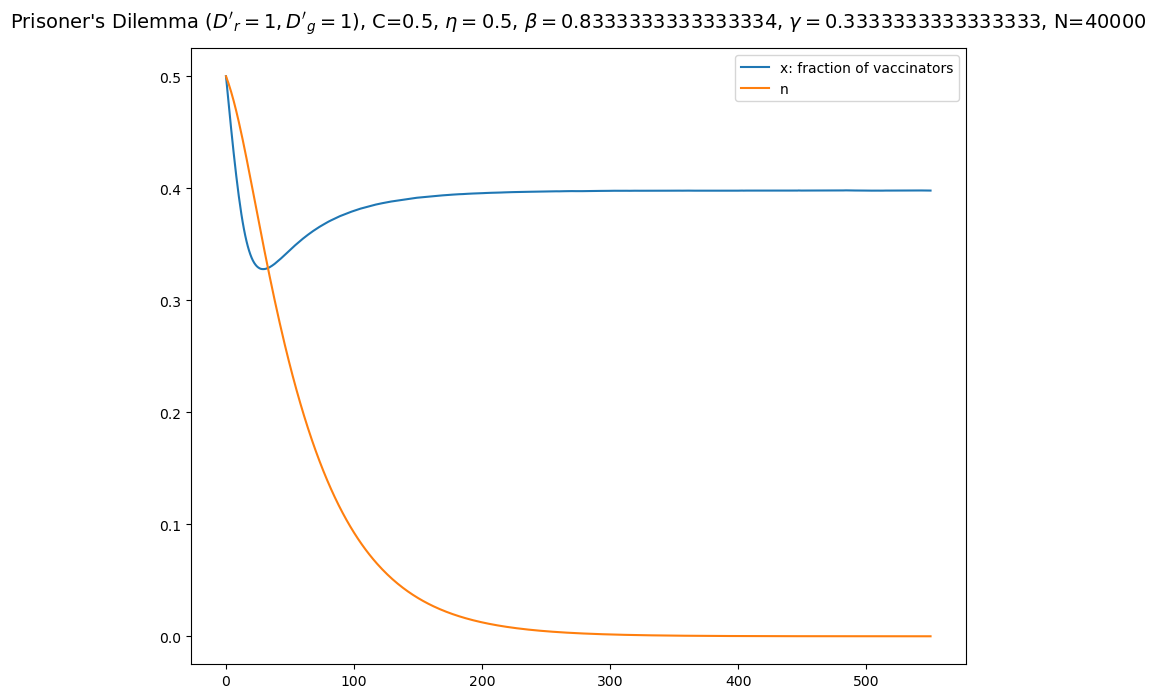

In [31]:
# Plots

def get_scatter_plot(l_params, g_params, x_seq, n_seq, color_seq, num_node):
    if len(color_seq) > len(x_seq):
        color_seq = color_seq[:len(x_seq)]

    fig = plt.figure(figsize=(10, 8))
    ax = plt.scatter(x_seq, n_seq, s=3, c=color_seq)
    plt.colorbar()

    if (g_params['Dr'] < 0):
        if (g_params['Dg']) < 0:
            game = 'Trivial'
        else:
            game = 'Chicken'
    else:
        if g_params['Dg'] < 0:
            game = 'Stag Hunt'
        else:
            game = "Prisoner's Dilemma"

    title = f"{game} ($D'_r={g_params['Dr']}, D'_g={g_params['Dg']}$), $\\theta={g_params['theta']}$, $\\eta={l_params["eta"]}, C={g_params["C"]}$, N={num_node}"
    plt.title(title, pad=15, fontdict={'fontsize': 14})
    plt.xlabel('fraction of vaccinators (cooperators), x', labelpad=10, fontdict={'fontsize': 12})
    plt.ylabel('environment, n', labelpad=10, fontdict={'fontsize': 12})
    # plt.gca().set_aspect('equal', adjustable='datalim')
    plt.xlim(0, 1)
    plt.ylim(0, 1)

    return

def get_plot(params, x_seq, y_seq, xlabel='x: fraction of vaccinators', ylabel='n'):
    l_params, g_params = params[1], params[2]
    num_node = params[0]['num_node']
    fig = plt.figure(figsize=(10, 8))
    ax = plt.subplot()
    ax.plot(x_seq, label=xlabel)
    ax.plot(y_seq, label=ylabel)
    ax.legend()
    
    if (g_params['Dr'] < 0):
        if (g_params['Dg']) < 0:
            game = 'Trivial'
        else:
            game = 'Chicken'
    else:
        if g_params['Dg'] < 0:
            game = 'Stag Hunt'
        else:
            game = "Prisoner's Dilemma"
    title = f"{game} ($D'_r={g_params['Dr']}, D'_g={g_params['Dg']}$), C={g_params["C"]}, $\\eta={l_params["eta"]}$, $\\beta={l_params["beta"]}$, $\\gamma={l_params["gamma"]}$, N={num_node}"
    plt.title(title, pad=15, fontdict={'fontsize': 14})
    return

# %matplotlib inline
# get_scatter_plot(local_params, global_params, x_seq, n_seq, color_seq, num_node)

# get_plot(x_seq, n_seq)
# get_plot(params_1, seq_result_1[0], seq_result_1[-2], ylabel='final epidemic size')
# get_plot(params_2, seq_result_2[0], seq_result_2[-2], ylabel='final epidemic size')
# get_plot(params_3, seq_result_3[0], seq_result_3[-2], ylabel='final epidemic size')
# get_plot(params_4, seq_result_4[0], seq_result_4[-2], ylabel='final epidemic size')

get_plot(params_PD, x_seq, n_seq)

# get_plot(local_params, global_params, payoff_C_seq, payoff_D_seq, 'Payoff C', 'Payoff D')
# get_plot(local_params, global_params, SFR_seq, FFR_seq, 'SFR', 'FFR')
# get_plot(local_params, global_params, HV_seq, IV_seq, 'HV', 'IV')

# df = pd.DataFrame([x_seq, n_seq, payoff_C_seq, payoff_D_seq, HV_seq, IV_seq, SFR_seq, FFR_seq], 
#              index=['x', 'n', 'payoff_C', 'payoff_D', 'HV_seq', 'IV_seq', 'SFR_seq', 'FFR_seq']).T

# df[100:150]

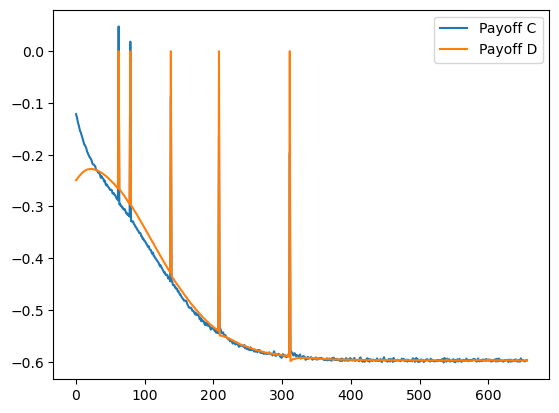

In [45]:
# Observe the data

# df = pd.read_csv(p / '1109_test' / '0.5_0.5_50_50.csv')
# df

get_plot(df['payoff_C'], df['payoff_D'], 'Payoff C', 'Payoff D')
# get_plot(df['x'], df['n'])

# p = Path('/Users/Jackie/Library/Mobile Documents/com~apple~CloudDocs/School/社會所RA/SIS model/data')
# df.to_csv(p / '1109_test' / '0.5_0.5_50_50.csv')

# cols = ['x', 'n', 'payoff_C', 'payoff_D', 'prob_C_to_D', 'prob_D_to_C']
# df[200:215]
# print(df[200:215][cols].to_latex(escape=True))
# print(df[305:320][cols].to_latex(escape=True))
# df['prob_C_to_D'] = 1 / (1 + np.exp(-(df['payoff_C'] - df['payoff_D']) / kappa))
# df['prob_D_to_C'] = 1 / (1 + np.exp(-(df['payoff_D'] - df['payoff_C']) / kappa))

In [33]:
def get_heatmap(data, index, columns, values):
    heatmap_data = data.pivot(index=index, columns=columns, values=values)
    heatmap_data.index = heatmap_data.index.round(1)
    heatmap_data.columns = heatmap_data.columns.round(1)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(heatmap_data, annot=True, fmt=".2f", vmin=0, vmax=1, cmap="viridis")
    return heatmap_data

### 重複 1000 次的 simulation

In [144]:
# 重複 1000 次的 simulation -> x_seq & n_seq

# x_seq_list = []
# n_seq_list = []
# time_list = []

# M, N, C, eta, beta, gamma = 150, 150, 0.8, 0.9, 0.6, 0.2

def run_global_iteration(x, n, g, M, N, C, eta, beta, gamma):
    start = time()
    # results = global_time_GPT(x, n, g, T=1000, num_node=num_node)
    params = get_params(M=M, N=N, C=C, eta=eta, beta=beta, gamma=gamma)
    # print(M, N, params[0]['num_node'], C, eta, beta, gamma)
    results = global_time_GPT(
        x, n, 
        g=params[0]['network'], 
        T=1000,
        num_node=params[0]['num_node'],
        local_params=params[1],
        global_params=params[2],
        return_equi=False
    )
    # results: x_seq_2, n_seq_2, color_seq_2, payoff_C_seq_2, payoff_D_seq_2, HV_seq_2, IV_seq_2, SFR_seq_2, FFR_seq_2
    end = time()
    elapsed_time = end - start

    # return only x, n, and time
    return results[:2], elapsed_time

def global_iteration(num_iter, M, N, C, eta, beta, gamma):
    # num_iter: number of global iterations

    results = Parallel(n_jobs=-1)(delayed(run_global_iteration)(x, n, g, M, N, C, eta, beta, gamma) for _ in range(num_iter))

    return results

# num_iter = 100
# global_iter_results = global_iteration(num_iter)

# for (x_seq, n_seq), elapsed_time in global_iter_results:
#     x_seq_list.append(x_seq)
#     n_seq_list.append(n_seq)
#     time_list.append(elapsed_time)

def n_global_sim(n_it, M, N, C, eta, beta, gamma):
    x_seq_list = []
    n_seq_list = []
    time_list = []

    # M, N, C, eta, beta, gamma = M, N, C, eta, beta, gamma
    global_iter_results = global_iteration(n_it, M, N, C, eta, beta, gamma)
    
    for (x_seq, n_seq), elapsed_time in global_iter_results:
        x_seq_list.append(x_seq)
        n_seq_list.append(n_seq)
        time_list.append(elapsed_time)

    params = (n_it, M, N, C, eta, beta, gamma)
    return x_seq_list, n_seq_list, time_list, params

# num_iter = 100
# n_global_sim(1, 30, 30, 0.7, 0.6, 0.4, 0.6)
# results_8962 = n_global_sim(100, 150, 150, 0.8, 0.9, 0.6, 0.2)
# results_8974 = n_global_sim(100, 150, 150, 0.8, 0.9, 0.7, 0.4)
# results_7646 = n_global_sim(100, 400, 400, 0.7, 0.6, 0.4, 0.6)
# results_7848 = n_global_sim(100, 200, 200, 0.7, 0.8, 0.4, 0.8)
# results_7948 = n_global_sim(100, 150, 150, 0.7, 0.9, 0.4, 0.8)

# results_3315_100 = n_global_sim(100, 100, 100, 0.3, 0.3, 1, 0.5)
# results_3315_400 = n_global_sim(100, 400, 400, 0.3, 0.3, 1, 0.5)
# results_3482_100 = n_global_sim(100, 100, 100, 0.3, 0.4, 0.8, 0.2)
# results_3482_400 = n_global_sim(100, 400, 400, 0.3, 0.4, 0.8, 0.2)
results_3681_100 = n_global_sim(100, 100, 100, 0.3, 0.6, 0.8, 0.1)
results_3681_400 = n_global_sim(100, 400, 400, 0.3, 0.6, 0.8, 0.1)

# time_list
# 6535	0.724698	0.991699	1.224944	0.206463	0.7	0.6	0.4	0.6
# 6636	0.774263	0.991469	1.172115	0.203634	0.7	0.7	0.4	0.7
# 6736	0.784123	0.991555	1.157595	0.227472	0.7	0.8	0.4	0.7
# 6737	0.820399	0.991539	1.120525	0.091312	0.7	0.8	0.4	0.8
# 6837	0.830105	0.991403	1.110666	0.092524	0.7	0.9	0.4	0.8

# 94	-0.569312	-0.994094	-1.550876	-0.564966	0.3	0.3	1.0	0.5
# 171	-0.569315	-0.994059	-1.551247	-0.564910	0.3	0.4	0.8	0.2
# 370	-0.569341	-0.994093	-1.551313	-0.564971	0.3	0.6	0.8	0.1

0.3 0.6 0.8 0.1 599.7570188045502
0.3 0.6 0.8 0.1 603.2741701602936
0.3 0.6 0.8 0.1 612.184455871582
0.3 0.6 0.8 0.1 613.4022159576416
0.3 0.6 0.8 0.1 639.8152267932892
0.3 0.6 0.8 0.1 643.0770170688629
0.3 0.6 0.8 0.1 681.1672909259796
0.3 0.6 0.8 0.1 914.1871180534363
0.3 0.6 0.8 0.1 612.1150379180908
0.3 0.6 0.8 0.1 645.2909731864929
0.3 0.6 0.8 0.1 624.8464958667755
0.3 0.6 0.8 0.1 693.1509091854095
0.3 0.6 0.8 0.1 642.0823740959167
0.3 0.6 0.8 0.1 736.9677419662476
0.3 0.6 0.8 0.1 721.7581481933594
0.3 0.6 0.8 0.1 836.8283162117004
0.3 0.6 0.8 0.1 642.9276361465454
0.3 0.6 0.8 0.1 676.9668130874634
0.3 0.6 0.8 0.1 677.4090118408203
0.3 0.6 0.8 0.1 761.3448488712311
0.3 0.6 0.8 0.1 712.4784069061279
0.3 0.6 0.8 0.1 719.4764969348907
0.3 0.6 0.8 0.1 784.6253759860992
0.3 0.6 0.8 0.1 695.4522290229797
0.3 0.6 0.8 0.1 670.423172712326
0.3 0.6 0.8 0.1 661.1205477714539
0.3 0.6 0.8 0.1 636.2835211753845
0.3 0.6 0.8 0.1 638.0278861522675
0.3 0.6 0.8 0.1 679.776891708374
0.3 0.6 0.8 0.1 6

In [111]:
results_7848 = n_global_sim(100, 800, 800, 0.7, 0.8, 0.4, 0.8)
# results_7848[3]

0.7 0.8 0.4 0.8 11234.2457280159
0.7 0.8 0.4 0.8 11320.24677681923
0.7 0.8 0.4 0.8 11342.315046072006
0.7 0.8 0.4 0.8 11459.668444871902
0.7 0.8 0.4 0.8 11547.014770030975
0.7 0.8 0.4 0.8 11563.744459152222
0.7 0.8 0.4 0.8 11706.153016805649
0.7 0.8 0.4 0.8 11769.295577049255
0.7 0.8 0.4 0.8 11094.494104146957
0.7 0.8 0.4 0.8 11392.909301996231
0.7 0.8 0.4 0.8 11005.915167093277
0.7 0.8 0.4 0.8 11592.38800406456
0.7 0.8 0.4 0.8 11376.414152145386
0.7 0.8 0.4 0.8 11396.579617023468
0.7 0.8 0.4 0.8 11380.71737408638
0.7 0.8 0.4 0.8 11601.899196863174
0.7 0.8 0.4 0.8 11597.757735967636
0.7 0.8 0.4 0.8 11438.924624204636
0.7 0.8 0.4 0.8 11225.478845119476
0.7 0.8 0.4 0.8 11383.861688137054
0.7 0.8 0.4 0.8 11475.39521598816
0.7 0.8 0.4 0.8 11536.626415729523
0.7 0.8 0.4 0.8 11392.385322093964
0.7 0.8 0.4 0.8 11623.815131902695
0.7 0.8 0.4 0.8 11071.99420285225
0.7 0.8 0.4 0.8 11111.154736995697
0.7 0.8 0.4 0.8 11310.923660993576
0.7 0.8 0.4 0.8 11391.243183135986
0.7 0.8 0.4 0.8 11697.41132

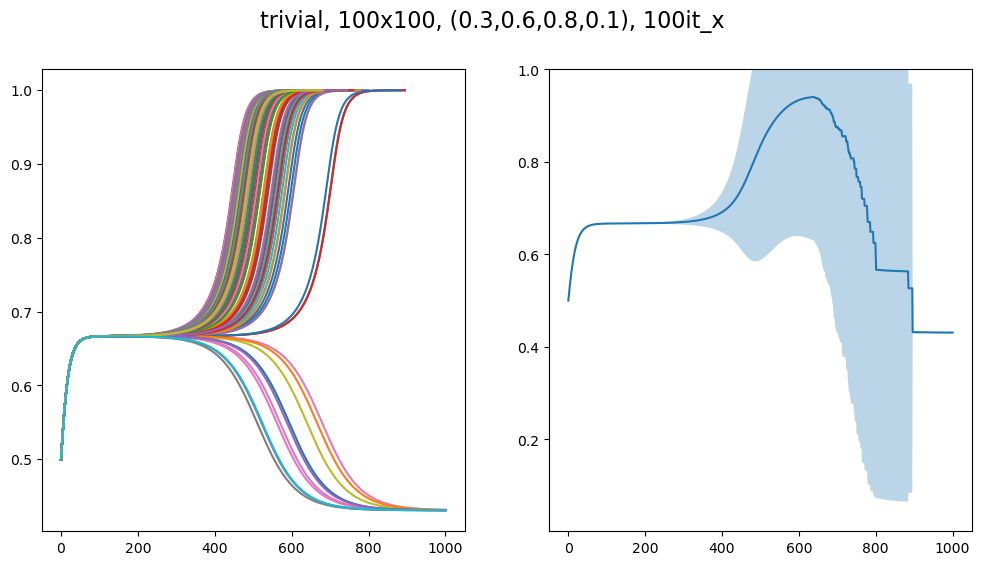

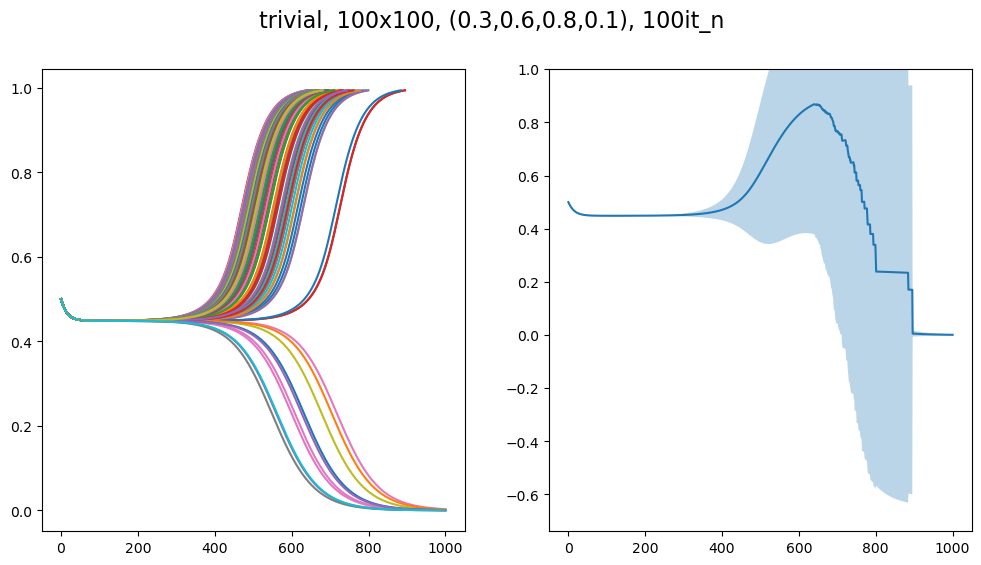

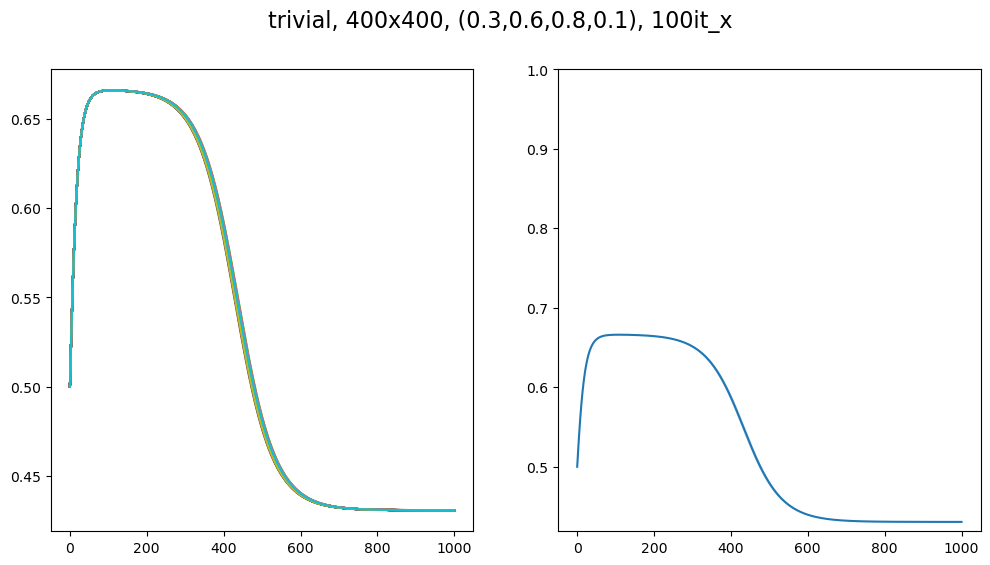

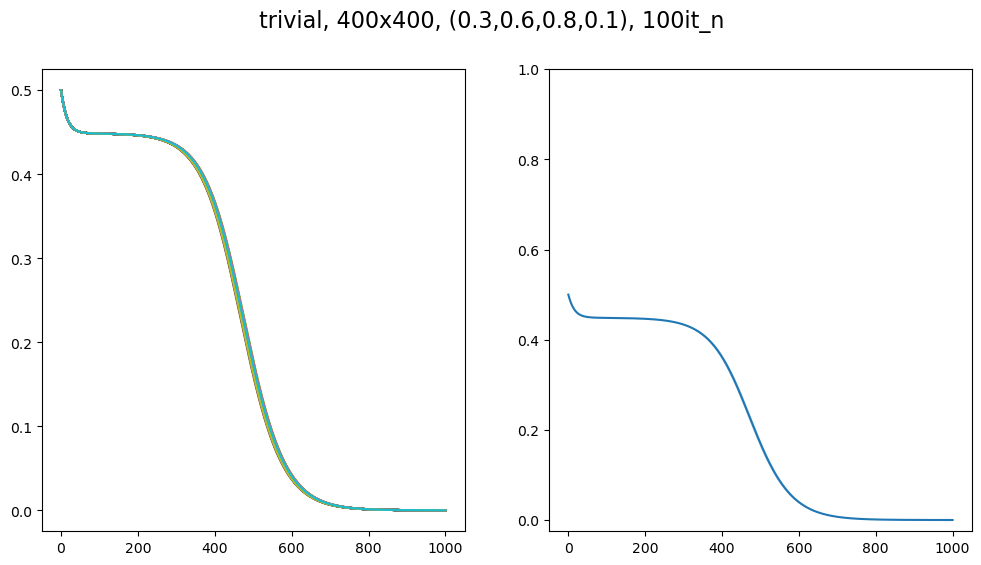

In [147]:
# Plots
# %matplotlib inline

p = Path('/Users/Jackie/Library/Mobile Documents/com~apple~CloudDocs/School/社會所RA/SIS model/data')

def seq_list_to_df(seq_list):
    df = pd.DataFrame(seq_list).T
    return df
 
def plot_seq_list(seq_list, title='', savefig=False):

    df = pd.DataFrame(seq_list).T

    means = df.mean(axis=1)
    stds = df.std(axis=1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    for i in df.columns:
        axes[0].plot(seq_list[i])

    axes[1].plot(means.index, means.values)
    axes[1].fill_between(means.index, (means - 2*stds).values, (means + 2*stds).values, alpha=0.3)

    fig.suptitle(title, fontsize=16)
    plt.ylim(top=1)

    if savefig:
        p = Path('/Users/Jackie/Library/Mobile Documents/com~apple~CloudDocs/School/社會所RA/SIS model/Figures/1010/1000it/')
        plt.savefig(p / f'{title}.png', dpi=500)
    return 

# 0118: 要修改，M, N, ... 輸入改成 params: tuple
def get_iter_plots(data, savedf=False):
    n_it, M, N, C, eta, beta, gamma = data[3]
    x_title = f'trivial, {M}x{N}, ({C},{eta},{beta},{gamma}), {n_it}it_x'
    n_title = f'trivial, {M}x{N}, ({C},{eta},{beta},{gamma}), {n_it}it_n'
    time_title = f'trivial, {M}x{N}, ({C},{eta},{beta},{gamma}), {n_it}it_time'

    x_seq_list = data[0]
    n_seq_list = data[1]
    time_list = data[2]

    savefig = False
    plot_seq_list(x_seq_list, title=x_title, savefig=savefig)
    plot_seq_list(n_seq_list, title=n_title, savefig=savefig)

    x_df = seq_list_to_df(x_seq_list)
    n_df = seq_list_to_df(n_seq_list)
    time_df = seq_list_to_df(time_list)
    
    if savedf:
        x_df.to_csv(p / '0220' / f'{x_title}.csv', index=False)
        n_df.to_csv(p / '0220' / f'{n_title}.csv', index=False)
        time_df.to_csv(p / '0220' / f'{time_title}.csv', index=False)
    return 

# x_title = f'trivial, {M}x{N}, ({C},{eta},{beta},{gamma}), {num_iter}it_x'
# n_title = f'trivial, {M}x{N}, ({C},{eta},{beta},{gamma}), {num_iter}it_n'
# time_title = f'trivial, {M}x{N}, ({C},{eta},{beta},{gamma}), {num_iter}it_time'

# savefig = False
# plot_seq_list(x_seq_list, title=x_title, savefig=savefig)
# plot_seq_list(n_seq_list, title=n_title, savefig=savefig)

# x_df = seq_list_to_df(x_seq_list)
# n_df = seq_list_to_df(n_seq_list)
# time_df = seq_list_to_df(time_list)

# x_df.to_csv(p / '0116' / f'{x_title}.csv', index=False)
# n_df.to_csv(p / '0116' / f'{n_title}.csv', index=False)
# time_df.to_csv(p / '0116' / f'{time_title}.csv', index=False)
# pd.DataFrame(time_list).to_csv(p / f'trivial, {M}x{N}, ({eta},{C}), 1000it_time.csv', index=False)

get_iter_plots(results_3681_100, True)
get_iter_plots(results_3681_400, True)

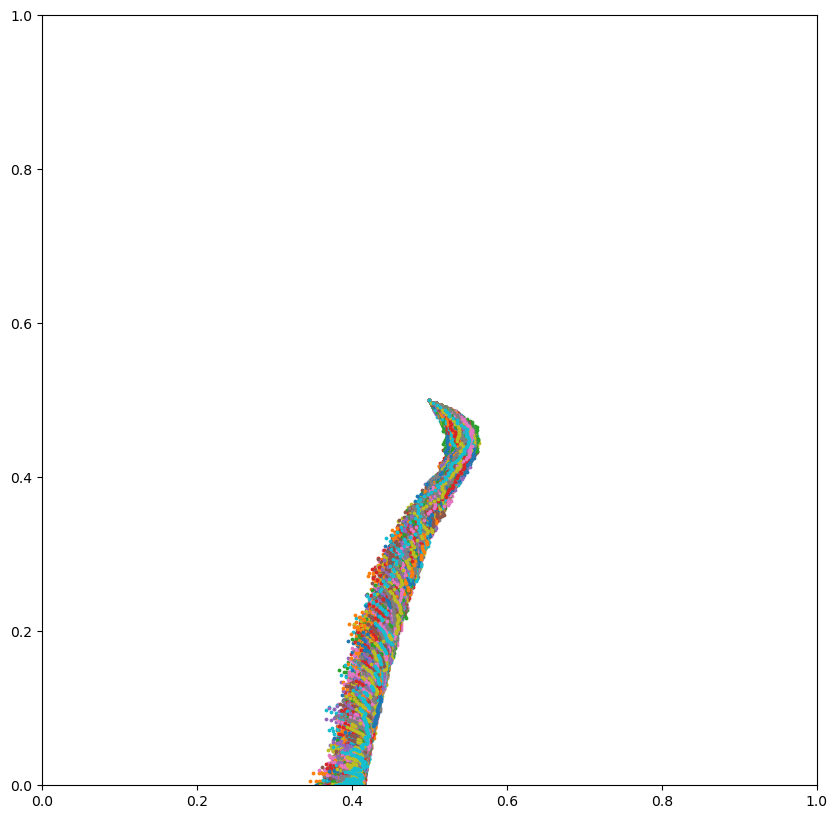

In [186]:
def get_scatter_plot_seq_list(x_seq_list, n_seq_list):
    x_df = pd.DataFrame(x_seq_list).T
    n_df = pd.DataFrame(n_seq_list).T
    
    # means = df.mean(axis=1)
    # stds = df.std(axis=1)

    fig = plt.figure(figsize=(10, 10))
    ax = plt.subplot()

    for i in x_df.columns:
        ax.scatter(x_seq_list[i], n_seq_list[i], s=3)

    plt.xlim(0, 1)
    plt.ylim(0, 1)
    
    return

get_scatter_plot_seq_list(x_seq_list, n_seq_list)

In [59]:
# eta = 0.5 時，prob_C_to_D 的初始值會越大

# results = global_time(x=0.5, n=1, T=100, local_params=local_params, return_equi=True)
fraction_of_vaccinator[eta].append(results[0])

### Model 1

In [ ]:
def Model1():
    # n, C, eta 作為變數
    x = 0.5

    col_names = ['x', 'n', 'payoff_C', 'payoff_D', 'init_n', 'init_eta', 'init_C']
    results_df = pd.DataFrame(columns=col_names)
    
    for C in [0.1, 0.5, 0.9]:
        for eta in np.arange(0, 1.01, 0.1):
            for n in np.arange(0, 1.01, 0.1):
                params = get_params(M=50, N=50, C=C, eta=eta, beta=5/6, gamma=1/3)
                results = global_time(
                    x, n, 
                    g=params[0]['network'], 
                    T=1000, 
                    num_node=params[0]['num_node'],
                    local_params=params[1],
                    global_params=params[2],
                    return_equi=True
                    )
                # results -> (x, n, payoff_C, payoff_D)

                df = pd.DataFrame(np.array((list(results) + [n, eta, C])), index=col_names).T
                results_df = pd.concat([results_df, df], axis=0)

    return results_df

# results = Model1()
# col_names = ['x', 'n', 'payoff_C', 'payoff_D']
# temp = pd.DataFrame(columns=col_names)
# for i in [4, 8, 12]:
#     temp = pd.concat([temp, pd.DataFrame(results_list[i-4:i], index=col_names).T], axis=0)

# temp

# np.array((col_names + ['C']))
# results
# results.rename(columns={'n':})
# results.to_csv(p / 'model1_n_eta_C_2500', index=False)

/var/folders/55/73cg_1sj16sgbfhd1gd__dy00000gp/T/ipykernel_41722/1140594350.py:27: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_df = pd.concat([results_df, df], axis=0)


,x,n,payoff_C,payoff_D,init_n,init_eta,init_C
0,1.0,0.99999,0.999984,0.0,0.5,0.9,0.5


In [ ]:
# By ChatGpT

from joblib import Parallel, delayed

def process_combination_1(C, eta, n, x=0.5):
    params = get_params(M=50, N=50, C=C, eta=eta, beta=5/6, gamma=1/3)
    result = global_time(
        x, n, 
        g=params[0]['network'], 
        T=1000, 
        num_node=params[0]['num_node'],
        local_params=params[1],
        global_params=params[2],
        return_equi=True
    )
    return list(result) + [n, eta, C]

def Model1():
    col_names = ['x', 'n', 'payoff_C', 'payoff_D', 'init_n', 'init_eta', 'init_C']
    # param_grid = itertools.product(
    #     [0.1, 0.5, 0.9], 
    #     np.arange(0, 1.01, 0.1), 
    #     np.arange(0, 1.01, 0.1)
    # )
    param_grid = itertools.product(
        [0.5], 
        [0.5], 
        [0.9]
    )
    
    # Parallelize the computations
    results = Parallel(n_jobs=-1)(
        delayed(process_combination_1)(C, eta, n) for C, eta, n in param_grid
    )
    
    # Create the DataFrame from all results
    results_df = pd.DataFrame(results, columns=col_names)
    return results_df

# results = Model1()

,x,n,payoff_C,payoff_D,init_n,init_eta,init_C
0,1.0,0.99999,0.999975,0.0,0.9,0.5,0.5


init_eta,0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0
init_n,,,,,,,,,,,
0.0,0.487655,0.487656,0.487652,0.487650,0.487653,0.487658,0.487655,0.487662,0.487651,0.487653,0.487651
0.1,0.331599,0.331899,0.331832,0.331670,0.331980,0.331957,0.331574,0.331698,0.331655,0.331767,0.332017
0.2,0.331811,0.331664,0.331421,0.331992,0.331600,0.331568,0.331638,0.331527,0.331665,0.331759,0.331858
0.3,0.331727,0.331537,0.331841,0.331711,0.331559,0.331470,0.331549,0.331911,0.331494,0.331548,0.331813
0.4,0.331522,0.331628,0.331887,0.331898,0.331576,0.331768,0.331723,0.331641,0.331567,0.331918,0.331625
0.5,0.331726,0.331791,0.331578,0.331680,0.331670,0.331602,0.331573,0.331564,0.331670,0.331543,0.331621
0.6,0.332140,0.331499,0.331654,0.331722,0.331640,0.331620,0.332014,0.331570,0.331574,0.331753,0.331501
0.7,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
0.8,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


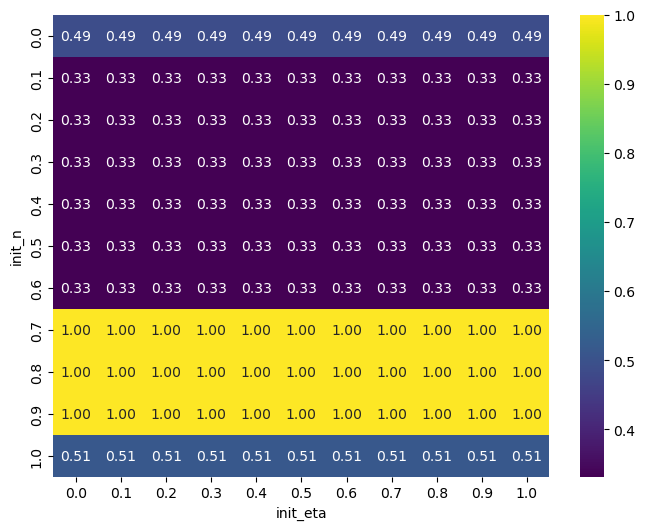

In [116]:
# Plot for model 1

# results_1 = pd.read_csv(p / '1201' / 'model1_n_eta_C_2500.csv')
# results_1

filt_1 = results_1['init_C'] == 0.1
filt_5 = results_1['init_C'] == 0.5
filt_9 = results_1['init_C'] == 0.9

# heatmap_data = results_1[filt].pivot(index='init_n', columns='init_eta', values='x')
# sns.heatmap(heatmap_data)

# distribution of x
# get_heatmap(results_1[filt_1], index='init_n', columns='init_eta', values='x')
# get_heatmap(results_1[filt_5], index='init_n', columns='init_eta', values='x')
get_heatmap(results_1[filt_9], index='init_n', columns='init_eta', values='x')

# distribution of n
# get_heatmap(results_1[filt_1], index='init_n', columns='init_eta', values='n')
# get_heatmap(results_1[filt_5], index='init_n', columns='init_eta', values='n')
# get_heatmap(results_1[filt_9], index='init_n', columns='init_eta', values='n')

# distribution of payoff_C
# get_heatmap(results_1[filt_1], index='init_n', columns='init_eta', values='payoff_C')
# get_heatmap(results_1[filt_5], index='init_n', columns='init_eta', values='payoff_C')
# get_heatmap(results_1[filt_9], index='init_n', columns='init_eta', values='payoff_C')

# distribution of payoff_D
# get_heatmap(results_1[filt_1], index='init_n', columns='init_eta', values='payoff_D')
# get_heatmap(results_1[filt_5], index='init_n', columns='init_eta', values='payoff_D')
# get_heatmap(results_1[filt_9], index='init_n', columns='init_eta', values='payoff_D')

# results_1[filt_5][results_1['init_eta'] == 0.9]

### Model 2

In [ ]:
def Model2():
    # C, eta, beta, gamma 作為變數
    x = 0.5
    n = 0.5
    
    # params = get_params(C, eta)

    col_names = [
        'x', 'n', 'payoff_C', 'payoff_D',
        'init_C', 'init_eta', 'init_beta', 'init_gamma'
        ]
    results_df = pd.DataFrame(columns=col_names)
    
    # for C in [0.1, 0.5, 0.9]:
    for C in [0.5]:
        # for eta in [0.1, 0.5, 0.9]:
        for eta in [0.1]:
            # for beta in np.arange(0, 1.01, 0.1):
            for beta in [0.8]:
                # for gamma in np.arange(0, 1.01, 0.1):
                for gamma in [0.3]:
                    params = get_params(M=40, N=40, C=C, eta=eta, beta=beta, gamma=gamma)
                    results = global_time(
                        x, n, 
                        g=params[0]['network'], 
                        T=1000, 
                        num_node=params[0]['num_node'],
                        local_params=params[1],
                        global_params=params[2],
                        return_equi=True
                        )
                    # results -> (x, n, payoff_C, payoff_D)

                    df = pd.DataFrame(np.array((list(results) + [C, eta, beta, gamma])), index=col_names).T
                    results_df = pd.concat([results_df, df], axis=0)

    return results_df

Model2_results = Model2()
Model2_results

In [9]:
# By ChatGPT

import gc

# 限制 BLAS / NumPy 每個 worker 只開 1 條線程
os.environ["OMP_NUM_THREADS"]      = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"]      = "1"


# param_grid = list(itertools.product(
#     np.arange(0.1, 1.01, 0.1), # C
#     np.arange(0.1, 1.01, 0.1), # eta
#     np.arange(0.1, 1.01, 0.1), # beta
#     np.arange(0.1, 1.01, 0.1)  # gamma
# ))

# 右上角
# param_grid = list(itertools.product(
#     np.arange(0.7, 0.81, 0.1), # C
#     np.arange(0.6, 1.01, 0.1), # eta
#     np.arange(0.1, 1.01, 0.1), # beta
#     np.arange(0.1, 1.01, 0.1)  # gamma
# ))

# 左上角
# param_grid = list(itertools.product(
#     np.arange(0.1, 0.21, 0.1), # C
#     np.arange(0.7, 1.01, 0.1), # eta
#     np.arange(0.1, 1.01, 0.1), # beta
#     np.arange(0.1, 1.01, 0.1)  # gamma
# ))

# Cross section, 切更細
param_grid = list(itertools.product(
    [0.7], # C
    [0.8], # eta
    np.arange(0.05, 1.001, 0.05), # beta
    [0.5]  # gamma
))

# param_grid = list(itertools.product(
#     [0.7], # C
#     [0.8], # eta
#     [0.1, 0.3, 0.5, 0.7, 0.9],  # beta
#     np.arange(0.05, 1.001, 0.05) # gamma
# ))

# param_grid = list(itertools.product(
#     [0.1, 0.3, 0.5, 0.7, 0.9], # C
#     np.arange(0.05, 1.001, 0.05), # eta
#     [0.2], # beta
#     [0.2]  # gamma
# ))

# param_grid = list(itertools.product(
#     np.arange(0.05, 1.001, 0.05), # C
#     [0.1, 0.3, 0.5, 0.7, 0.9], # eta
#     [0.2], # beta
#     [0.2]  # gamma
# ))

col_names = [
        'x', 'n', 'payoff_C', 'payoff_D', 'epi_size',
        'C', 'eta', 'beta', 'gamma'
        ]

# results = []

# for C, eta, beta, gamma in param_grid:
#     params = get_params(C=C, eta=eta, beta=beta, gamma=gamma)
#     result = global_time(
#         x, n, 
#         g=params[0]['network'], 
#         T=1000, 
#         num_node=params[0]['num_node'],
#         local_params=params[1],
#         global_params=params[2],
#         return_equi=True
#     )
#     # Collect results
#     results.append(list(result) + [C, eta, beta, gamma])

# # Convert all results to a single DataFrame at once
# results_df = pd.DataFrame(results, columns=col_names)

def process_combination(C, eta, beta, gamma):
    try:
        # M, N 可修改
        # M, N = 50, 50
        # M, N = 100, 100
        M, N = 800, 800                      # ★ 若記憶體仍吃緊先降到 600×600 試
        params = get_params(M=M, N=N, C=C, eta=eta, beta=beta,
                            gamma=gamma, Dr=-1, Dg=-1)

        result = global_time_GPT(
            x=0.5, n=0.5,
            g=params[0]['network'],
            local_params=params[1],
            global_params=params[2],
            T=1000,
            num_node=params[0]['num_node'],
            return_equi=True
        )
        return list(result) + [C, eta, beta, gamma]

    except Exception as e:
        # 把錯誤打印到 stderr；DataFrame 補 NaN 方便後續檢查
        print(f"[ERR] C={C} eta={eta} beta={beta} gamma={gamma}: {e}",
              file=sys.stderr)
        traceback.print_exc()
        return [np.nan] * (len(col_names) - 4) + [C, eta, beta, gamma]

# 3. 做並行
# N_JOBS = max(1, os.cpu_count() - 1)   # 實體核心 - 1
# print(f"Using {N_JOBS} worker processes…")

# results = Parallel(
#     n_jobs=N_JOBS,
#     backend="loky",          # 預設；寫明可讀
#     mmap_mode="r",           # 共享父進程可能傳遞的大陣列
#     verbose=10,              # 每批任務有進度顯示
# )(
#     delayed(process_combination)(C, eta, beta, gamma)
#     for C, eta, beta, gamma in param_grid
# )

N_JOBS = max(1, os.cpu_count() - 1)   # 實體核心 - 1
param_chunks = np.array_split(param_grid, 4)   # 4 批跑完

all_results = []
for chunk in param_chunks:
    res = Parallel(
        n_jobs=N_JOBS,
        backend="loky",
        mmap_mode="r",
        verbose=10
    )(delayed(process_combination)(C, eta, beta, gamma)
      for C, eta, beta, gamma in chunk)
    all_results.extend(res)

    # 釋放記憶體
    del res
    gc.collect()

# Convert to DataFrame
results_df = pd.DataFrame(all_results, columns=col_names)
# results_df

[Parallel(n_jobs=7)]: Using backend LokyBackend with 7 concurrent workers.


0.7 0.8 0.05 0.5 8870.854388952255
0.7 0.8 0.1 0.5 11228.129055976868


[Parallel(n_jobs=7)]: Done   2 out of   5 | elapsed: 187.4min remaining: 281.1min


0.7 0.8 0.15000000000000002 0.5 14054.480638980865


[Parallel(n_jobs=7)]: Done   3 out of   5 | elapsed: 234.5min remaining: 156.3min


...

[Parallel(n_jobs=7)]: Done   2 out of   5 | elapsed: 418.8min remaining: 628.3min


0.7 0.8 0.9 0.5 28712.13476705551


[Parallel(n_jobs=7)]: Done   3 out of   5 | elapsed: 478.9min remaining: 319.3min


0.7 0.8 1.0 0.5 43153.238564014435
0.7 0.8 0.9500000000000001 0.5 54356.92345523834


[Parallel(n_jobs=7)]: Done   5 out of   5 | elapsed: 907.4min finished


In [ ]:
results_df
results_df.to_csv(p / '250529' / 'Model2_640000_beta50_gamma0.5.csv', index=False)

NameError: name 'results_df' is not defined

In [42]:
def get_diff_df(df1, df2):
    df1 = df1.reset_index(drop=True)
    df2 = df2.reset_index(drop=True)
    diff_df = df1.copy(deep=True)

    cols = ['x', 'n', 'payoff_C', 'payoff_D', 'epi_size']
    diff_df[cols] = df2[cols] - df1[cols]
    # for col in ['x', 'n', 'payoff_C', 'payoff_D']:
    #     diff_df[col] = df2[col] - df1[col]

    return diff_df

# Display results

# results_df.to_csv(p / '0205' / 'Model2_10000_partial.csv', index=False)
# results_50 = pd.read_csv(p / '0501' / 'Model2_2500_PD.csv')
# results_100 = pd.read_csv(p / '0501' / 'Model2_10000_PD.csv')

# for col in ['C', 'eta', 'gamma', 'beta']:
#     results[f'{col}'] = results[f'{col}'].round(1)

# get_heatmap(data=results[(results['C'] == 0.8) & (results['eta'] == 0.8)], 
#             index='beta', 
#             columns='gamma', 
#             values='x')

# To see the difference between 50*50 and 100*100
results_50 = pd.read_csv(p / '250501' / 'Model2_2500_PD.csv')
results_100 = pd.read_csv(p / '250501' / 'Model2_10000_PD.csv')

for col in ['C', 'eta', 'gamma', 'beta', 'epi_size']:
    results_100 = results_100.rename(columns={f'init_{col}': col})
    results_100[f'{col}'] = results_100[f'{col}'].round(1)

# 100*100 - 50*50
diff_df = get_diff_df(results_50, results_100)
# diff_df

# diff_df[diff_df['x'] >= 0.1]
# results_50[(results_50['init_C'] == 0.8) & (results_50['init_eta'] == 0.9) & (results_50['init_beta'] > 0.6)]
# results_100[(results_100['init_C'] == 0.8) & (results_100['init_eta'] == 0.9) & (results_100['init_beta'] > 0.6)]

# Difference between 100*100 and 200*200
# C == 0.7, 0.8
# eta >= 0.6

# C_filt = (results_100['C'] == 0.3)
# eta_filt = (results_100['eta'] >= 0.3) & (results_100['eta'] <= 0.6)
# results_100_partial = results_100[C_filt & eta_filt]

# results

# diff_df = get_diff_df(results_100_partial, results)
# diff_df[abs(diff_df['x']) >= 0.001]
# results_100_partial.reset_index()[['x', 'n', 'payoff_C', 'payoff_D']] - results[['x', 'n', 'payoff_C', 'payoff_D']]

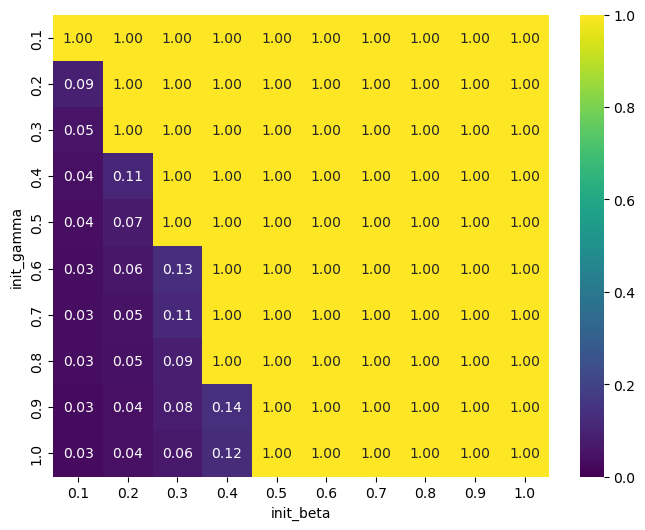

In [116]:
# Plots for Model 2

# results_2 = pd.read_csv(p / '1201' / 'Model2_1600.csv')
# results
temp = results[(results['init_C'] == 0.7) & (results['init_eta'] == 1)]
get_heatmap(data=temp, index='init_gamma', columns='init_beta', values='x')
plt.show()



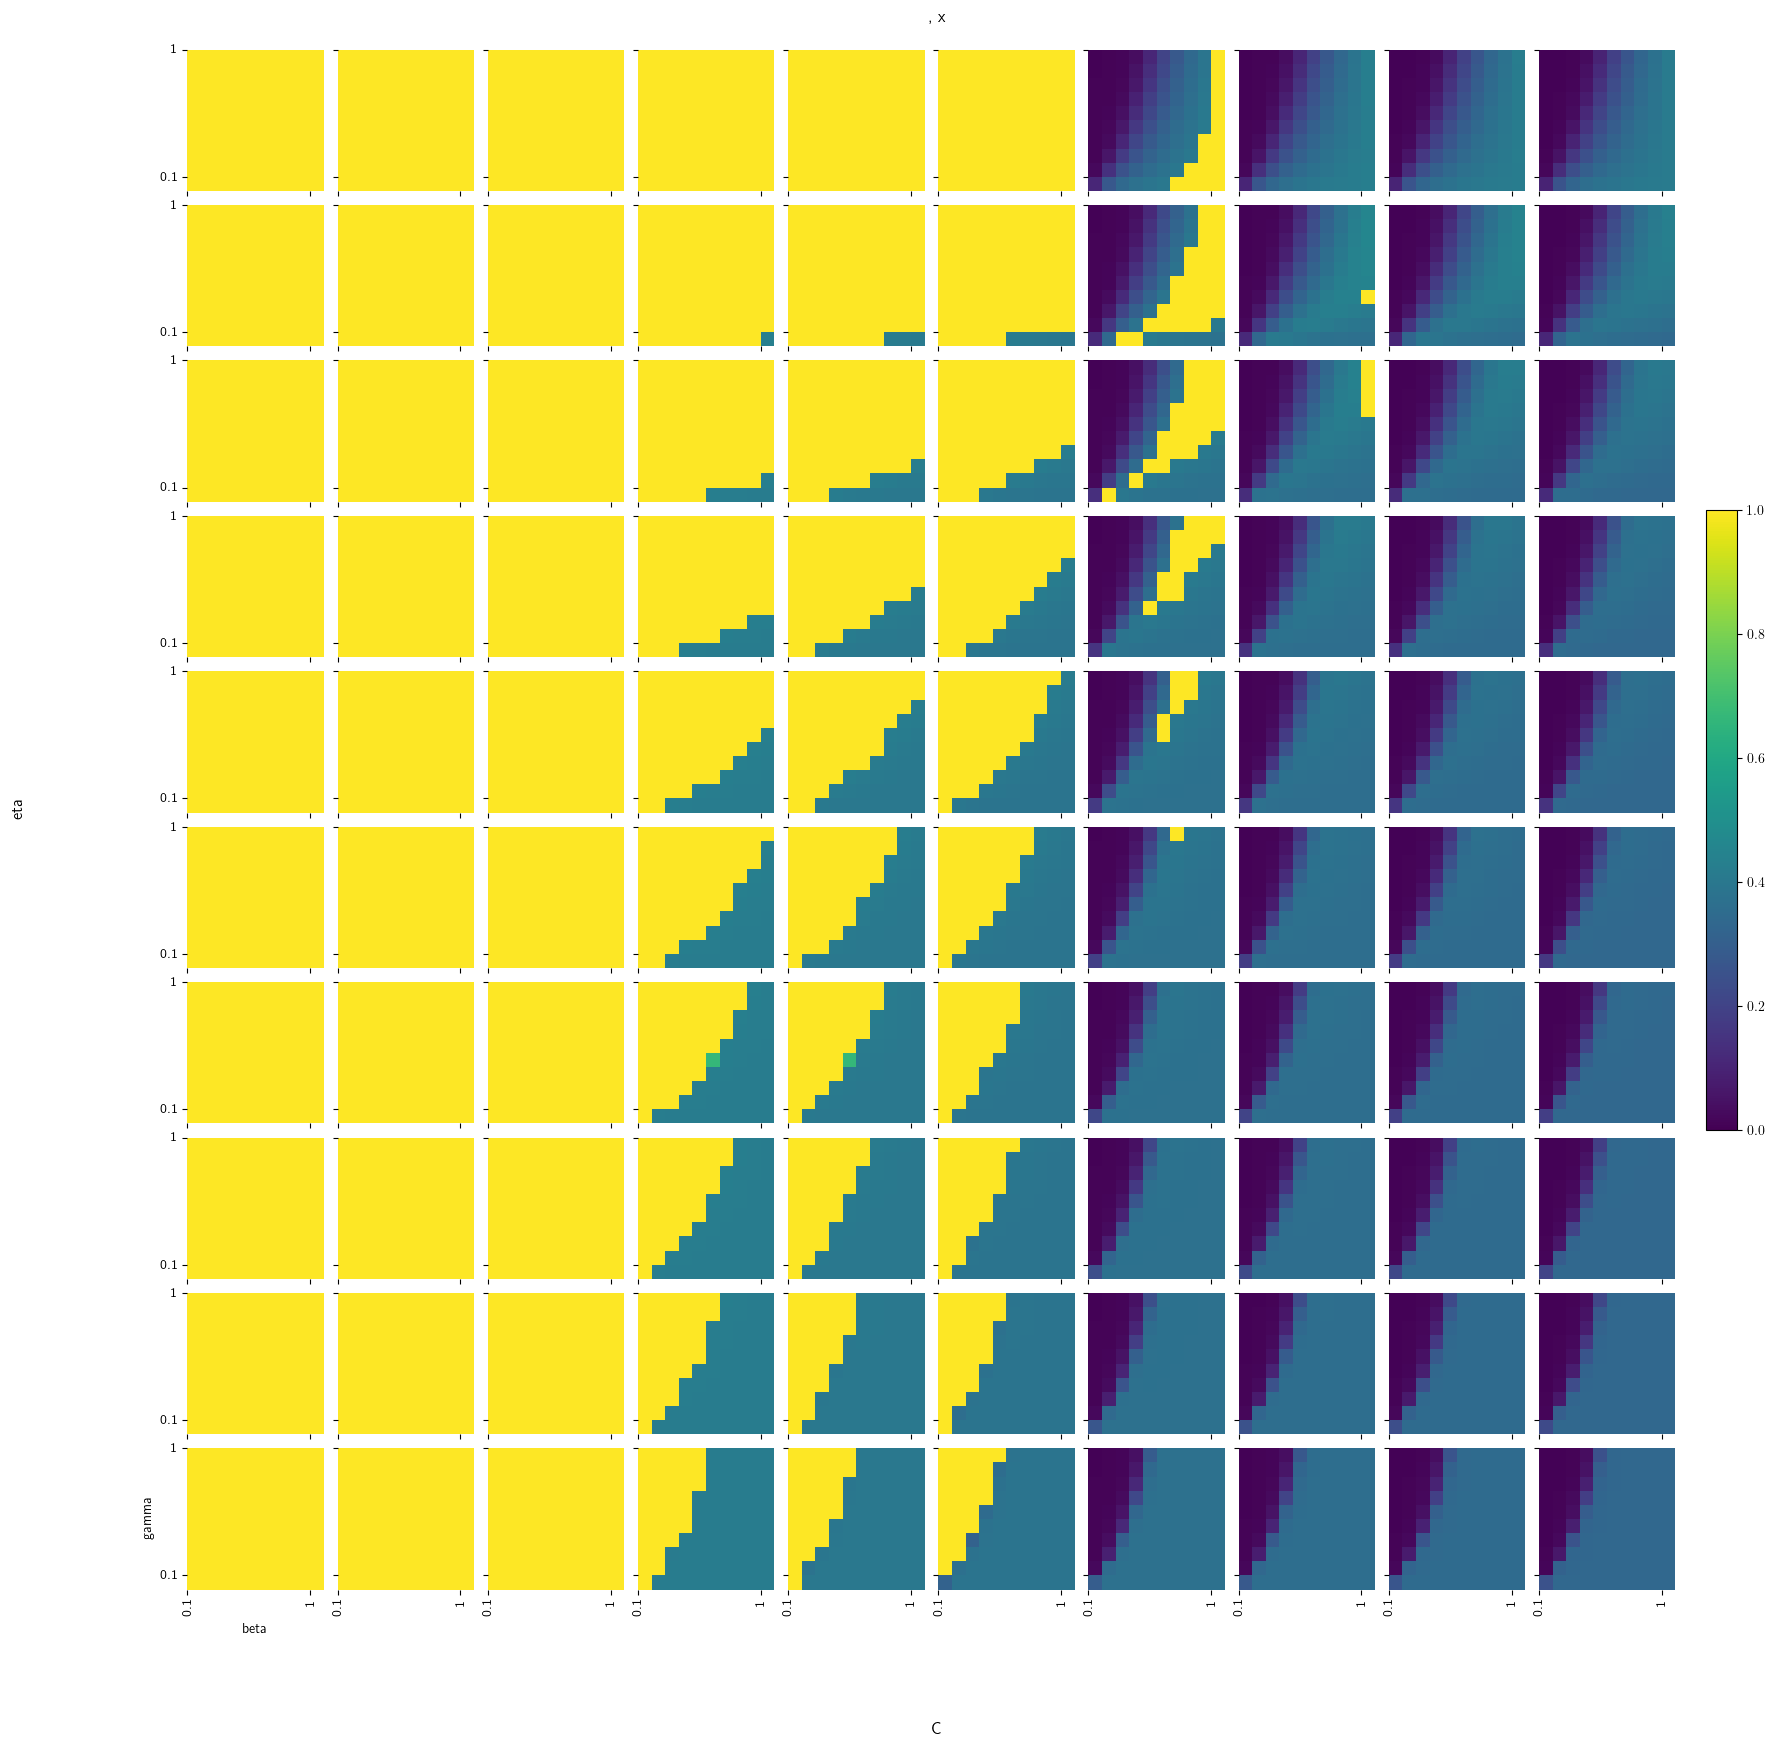

In [4]:
def get_double_plot(data, col='x', title='Model2'):
    # Get unique values for outer and inner axes
    outer_x = sorted(data['C'].unique())
    outer_y = sorted(data['eta'].unique(), reverse=True)
    inner_x = sorted(data['beta'].unique())
    inner_y = sorted(data['gamma'].unique())

    # Pre-compute pivot tables for efficiency
    pivot_tables = {}
    for eta in outer_y:
        for C in outer_x:
            subset = data[(data['C'] == C) & (data['eta'] == eta)]
            pivot_tables[(eta, C)] = subset.pivot(index='gamma', columns='beta', values=col)

    # Create a grid of subplots
    fig, axes = plt.subplots(len(outer_y), len(outer_x), figsize=(20, 20), sharex=True, sharey=True)
    # fig, axes = plt.subplots(len(outer_y), len(outer_x), figsize=(10, 20), sharex=True, sharey=True)
    fig.subplots_adjust(wspace=0.1, hspace=0.1)

    # min and max for heat maps
    if col == 'payoff_D':
        # payoff_D <= 0 because D'_g = -1
        vmin = -1
        vmax = 0
    elif col == 'payoff_C':
        vmin = -1
        vmax = 1
    else:
        vmin = 0
        vmax = 1

    # Iterate over the outer grid
    for i, eta in enumerate(outer_y):
        for j, C in enumerate(outer_x):
            # Retrieve pre-computed pivot table
            pivot_table = pivot_tables[(eta, C)]
            
            # Plot the inner heatmap
            ax = axes[i, j]
            sns.heatmap(pivot_table[::-1], ax=ax, cbar=False,
                        cbar_kws={"shrink": 0.8}, vmin=vmin, vmax=vmax, cmap="viridis")
            
            # Set inner ticks
            ax.set_xticks([0, len(inner_x) - 1])
            ax.set_xticklabels(["0.1", "1"])
            ax.set_yticks([0, len(inner_y) - 1])
            ax.set_yticklabels(["0.1", "1"])

    # print(pivot_tables[(1, 1)])
            
    # Add overall outer x and y labels
    fig.text(0.5, 0.04, 'C', ha='center', va='center', fontsize=12)
    fig.text(0.04, 0.5, 'eta', ha='center', va='center', rotation='vertical', fontsize=12)

    # Add inner x and y labels for the left-below subplot
    axes[-1, 0].set_xlabel('beta', fontsize=10)
    axes[-1, 0].set_ylabel('gamma', fontsize=10)

    # # Add outer x-ticks below the left-below and right-below subplots
    # axes[-1, 0].set_xticks([0, len(inner_x) - 1])
    # axes[-1, 0].set_xticklabels(["0.1", "1"])
    # axes[-1, -1].set_xticks([0, len(inner_x) - 1])
    # axes[-1, -1].set_xticklabels(["0.1", "1"])

    # Add outer y-ticks with 0.1 below and 1 above
    axes[0, 0].set_yticks([0, len(inner_y) - 1])
    axes[0, 0].set_yticklabels(["1", "0.1"])
    axes[-1, 0].set_yticks([0, len(inner_y) - 1])
    axes[-1, 0].set_yticklabels(["1", "0.1"])

    # Position specific ticks for outer x and y axes
    # axes[-1, 0].set_xticks([0, len(outer_x) - 1])
    # axes[-1, 0].set_xticklabels(["0.1", "1"])
    # axes[0, 0].set_yticks([0, len(outer_y) - 1])
    # axes[0, 0].set_yticklabels(["0.1", "1"])

    # Remove unnecessary labels
    for i, ax_row in enumerate(axes):
        for j, ax in enumerate(ax_row):
            if not (i == len(outer_y) - 1 and j == 0):
                ax.set_xlabel('')
                ax.set_ylabel('')

    # Add an overall colorbar
    norm = plt.Normalize(vmin=vmin, vmax=vmax)
    fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap="viridis"), ax=axes, orientation='vertical', fraction=0.02, pad=0.02)

    plt.suptitle(f'{title}, {col}', y=0.9)
    plt.show()
    return

# %matplotlib inline
# get_double_plot(results_df, 'x', 'Model2 50*50 (PD)')
# get_double_plot(results_df, 'n', 'Model2 50*50 (PD)')
# get_double_plot(results_df, 'epi_size', 'Model2 50*50 (PD)')
# get_double_plot(results_df, 'payoff_C', 'Model2 50*50 (PD)')
# get_double_plot(results_df, 'payoff_D', 'Model2 50*50 (PD)')
get_double_plot(df, 'x', '')

# difference between 50*50 and 100*100
# get_double_plot(diff_df, 'x', 'Model2 Diff Between 50*50 & 100*100 (PD)')
# get_double_plot(diff_df, 'epi_size', 'Model2 Diff Between 50*50 & 100*100 (PD)')

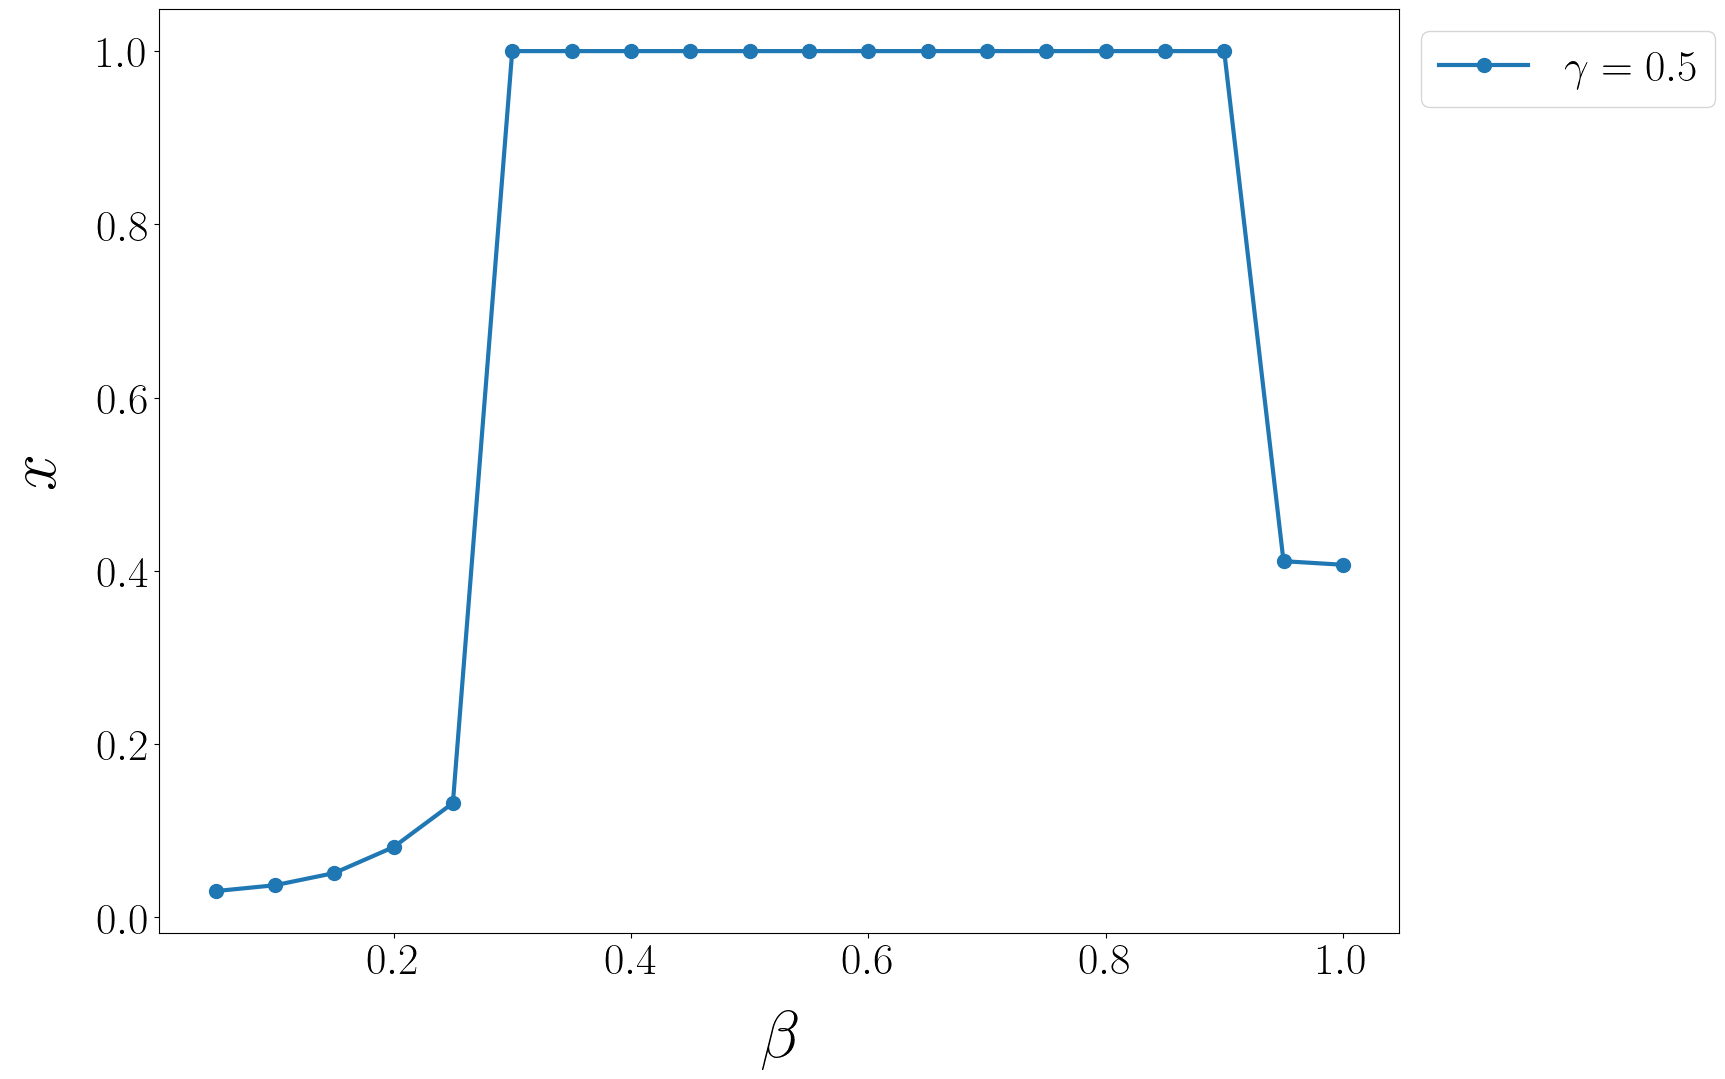

In [10]:
def plot_cross_section(data, dep_var, indep_var, fixed_param_sets):
    plt.figure(figsize=(16, 12))
    # Filter the data based on fixed parameters
    # filtered_data = data.copy()
    # for param, value in fixed_params.items():
    #     if param in data.columns:
    #         filtered_data = filtered_data[filtered_data[param] == value]

    # # Check if there is data left after filtering
    # if filtered_data.empty:
    #     print("No data available after filtering. Please adjust the fixed parameters.")
    #     return

    # Plot for each set of fixed parameters
    markers = ['o', 'v', 's', '*', 'x', 'D', '+']
    for i, fixed_params in enumerate(fixed_param_sets):
        # Filter the data
        filtered_data = data.copy()
        for param, value in fixed_params.items():
            if param in data.columns:
                filtered_data = filtered_data[filtered_data[param] == value]

        # Check if data is available
        if filtered_data.empty:
            print(f"No data available for {fixed_params}. Skipping.")
            continue

        # Generate label for the current line
        # label = ", ".join(f"{k}={v}" for k, v in fixed_params.items() if k != indep_var)
        vari = list(fixed_params.items())[-1][0]
        if vari != 'C':
            vari = f"\\{vari}"
        val = list(fixed_params.items())[-1][1]
        label = f"${vari} = {str(val)}$"
        
        # Plot the data
        marker = markers[i % len(markers)]
        plt.plot(filtered_data[indep_var], filtered_data[dep_var], marker=marker, linestyle='-', label=label, markersize=10, linewidth=3)
    
    # Plot x against the chosen independent variable
    # plt.figure(figsize=(8, 6))
    # plt.plot(filtered_data[indep_var], filtered_data[dep_var], marker='o', linestyle='-')
    # plt.xlabel(indep_var, fontsize=14)
    # plt.ylabel(dep_var, fontsize=14)
    # title_params = ", ".join(f"{k}={v}" for k, v in fixed_params.items())
    # plt.title(f'{dep_var} vs {indep_var} ({title_params})', fontsize=16)
    # plt.grid(True)
    # plt.show()
    
    # Customize the plot
    if indep_var == 'C':
        plt.xlabel(f'${indep_var}$', fontsize=48, labelpad=20)
    else:
        plt.xlabel(f'$\\{indep_var}$', fontsize=48, labelpad=20)
    plt.ylabel(f'${dep_var}$', fontsize=48, labelpad=20)
    # plt.title(f'{dep_var} vs {indep_var} for multiple conditions', fontsize=16)
    plt.legend(fontsize=32, loc='upper left', bbox_to_anchor=(1, 1))
    # plt.grid(Fal)
    plt.tick_params(axis='both', which='major', labelsize=32)
    plt.show()
    
    return

plot_cross_section(
    data=results_df, 
    dep_var='x', 
    indep_var='beta',
    fixed_param_sets=[
        # {'C': 0.7, 'eta': 0.8, 'gamma': 0.1},
        # {'C': 0.7, 'eta': 0.8, 'gamma': 0.3},
        {'C': 0.7, 'eta': 0.8, 'gamma': 0.5},
        # {'C': 0.7, 'eta': 0.8, 'gamma': 0.7},
        # {'C': 0.7, 'eta': 0.8, 'gamma': 0.9}
    ])

# plot_cross_section(
#     data=results_df, 
#     dep_var='x', 
#     indep_var='gamma',
#     fixed_param_sets=[
#         {'C': 0.7, 'eta': 0.8, 'beta': 0.1},
#         {'C': 0.7, 'eta': 0.8, 'beta': 0.3},
#         {'C': 0.7, 'eta': 0.8, 'beta': 0.5},
#         {'C': 0.7, 'eta': 0.8, 'beta': 0.7},
#         {'C': 0.7, 'eta': 0.8, 'beta': 0.9}
#     ])

# plot_cross_section(
#     data=results_df, 
#     dep_var='x', 
#     indep_var='eta',
#     fixed_param_sets=[
#         {'beta': 0.2, 'gamma': 0.2, 'C': 0.1},
#         {'beta': 0.2, 'gamma': 0.2, 'C': 0.3},
#         {'beta': 0.2, 'gamma': 0.2, 'C': 0.5},
#         {'beta': 0.2, 'gamma': 0.2, 'C': 0.7},
#         {'beta': 0.2, 'gamma': 0.2, 'C': 0.9},
#     ])

# plot_cross_section(
#     data=results_df, 
#     dep_var='x', 
#     indep_var='C',
#     fixed_param_sets=[
#         {'beta': 0.2, 'gamma': 0.2, 'eta': 0.1},
#         {'beta': 0.2, 'gamma': 0.2, 'eta': 0.3},
#         {'beta': 0.2, 'gamma': 0.2, 'eta': 0.5},
#         {'beta': 0.2, 'gamma': 0.2, 'eta': 0.7},
#         {'beta': 0.2, 'gamma': 0.2, 'eta': 0.9},
#     ])

In [98]:
# 每個 global time 的時間 text -> dataframe

iter_time_df = pd.read_csv(p / '0106' / '100*100_time.txt', sep=' ', header=None,
                           names=['C', 'eta', 'beta', 'gamma', 'time'])

# iter_time_df.sort_values(by='time', ascending=True)[2000:2050]
iter_time_df[['C', 'eta', 'beta', 'gamma']] = iter_time_df[['C', 'eta', 'beta', 'gamma']].round(1)
iter_time_df
iter_time_df[(iter_time_df['C'] == 0.7) & (iter_time_df['eta'] == 0.8) & (iter_time_df['beta'] == 0.4)]

,C,eta,beta,gamma,time
6728,0.7,0.8,0.4,0.6,35.307038
6729,0.7,0.8,0.4,0.5,44.077086
6730,0.7,0.8,0.4,0.4,58.014883
6732,0.7,0.8,0.4,0.3,88.684290
6733,0.7,0.8,0.4,0.7,32.696112
6734,0.7,0.8,0.4,0.8,36.238091
6735,0.7,0.8,0.4,1.0,62.926208
6736,0.7,0.8,0.4,0.9,75.930064
6737,0.7,0.8,0.4,0.2,194.758836
6756,0.7,0.8,0.4,0.1,702.272940
